<a href="https://colab.research.google.com/github/izabelaandrade-pos/mvp-puc-analise-dados/blob/main/Sprint2_MVP_Analise_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Análise de Dados e Boas Práticas**

**Nome:** Izabela Gregório de Andrade

**Matrícula:** 4052025001738

**Dataset:** [Used Cars](https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-analise-dados/refs/heads/main/used_cars.csv)

#1. Descrição do Problema

O presente projeto objetiva estudar como um conjunto de características de veículos usados (como marca, modelo e quilometragem) influencia na determinação de seu valor de mercado.

A motivação para este estudo é contribuir para que indivíduos interessados em vender seus automóveis usados estejam melhor informados na escolha do preço de seus anúncios. Uma estimativa assertiva do valor de venda pode potencializar as negociações, reduzindo o tempo de permanência do veículo à venda.

Esta etapa do projeto tratará da Análise e Pré-Processamento dos dados, fundamentais para garantir a qualidade das informações que servirão de base para a construção do modelo final.

## Hipóteses Levantadas

A partir do estudo do dataset selecionado, gostaríamos de validar as seguintes hipóteses:

1. **Tendência de Depreciação por Idade:** Nos principais segmentos, quanto mais antigos os modelos, menor o preço do automóvel.

2. **Relação entre Uso e Valor:** Nos principais segmentos, veículos com maior quilometragem acumulada apresentam preços inferiores aos de baixa quilometragem.

3. **Colinearidade entre Variáveis de Desgaste:** Existe uma forte correlação positiva entre a quilometragem e a idade de cada veículo (carros mais novos tendem a ter menos milhas rodadas).

4. **Impacto do Histórico de Acidentes:** O registro de acidentes prévios desvaloriza o automóvel em comparação com veículos similares sem sinistro.

5. **Prevalência da Transmissão Automática:** Veículos mais novos apresentam uma proporção de câmbio automático significativamente superior à observada em modelos mais antigos.







## Tipo de Problema

Este é um problema de **regressão supervisionada**. Dado um conjunto de atributos de um veículo (como marca, modelo, ano, quilometragem, etc), o objetivo é prever o seu preço de mercado.

Nossa variável target está contida na coluna *price*, variável numérica e contínua.

#2. Descrição da base de dados

## Fonte e seleção dos dados

O dataset "Used Car Price Prediction" é composto por informações coletadas via web scraping no marketplace americano https://www.cars.com.

Estes dados foram disponibilizados na plataforma Kaggle, através do endereço: https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset/data  sob licença  [Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).

Para fins deste projeto, o arquivo CSV foi espelhado no respectivo repositório GitHub para garantir a reprodutibilidade da análise, estando disponível em: https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-analise-dados/refs/heads/main/used_cars.csv  

Este conjunto de dados reflete anúncios reais e ativos no marketplace descrito no ano de 2023, servindo como estudo da dinâmica de preços naquele período específico.


## Dicionário de dados

O dataset em estudo apresenta 4.009 instâncias, em que cada uma representa o anúncio de um veículo único, e inclui doze atributos distintos descritos abaixo:

***brand:*** Identifica o nome da marca ou empresa

***model:*** Identifica o modelo específico de cada veículo.

***model_year:*** Apresenta o ano de fabricação dos veículos, crucial para avaliar a depreciação e os avanços tecnológicos.

***milage:*** Obtém a quilometragem (em milhas) de cada veículo, um indicador fundamental de desgaste e possíveis requisitos de manutenção.

***fuel_type:*** Informa sobre o tipo de combustível que os veículos utilizam, seja gasolina, diesel, elétrico ou híbrido.

***engine:*** Detalha as especificações do motor, esclarecendo aspectos de desempenho e eficiência.

***transmission:*** Determina o tipo de transmissão, seja automática, manual ou outra variante.

***ext_col:*** Explora o aspecto estético da cor externa dos veículos.

***int_col:*** Explora o aspecto estético da cor interna dos veículos.

***accident:*** Revela se um veículo possui histórico prévio de acidentes ou danos, algo crucial para uma tomada de decisão informada.

***clean_title:*** Avalia a disponibilidade de um título "limpo" (sem pendências legais ou sinistros graves), o que pode impactar o valor de revenda e o status legal do veículo.

***price:*** Fornece os preços (em dólares) listados para cada veículo, auxiliando na comparação de valores.

# 3. Importação de bibliotecas e carga de dados

Nesta etapa, realizamos o carregamento do ambiente de trabalho com as bibliotecas essenciais para a manipulação, visualização e pré-processamento dos dados, além da importação do dataset diretamente do repositório remoto.

As ferramentas selecionadas incluem:

* Pandas e NumPy: Para manipulação de estruturas de dados e operações matemáticas.

* Matplotlib e Seaborn: Para a geração de visualizações estatísticas e análise exploratória.

* Scipy (pearsonr): Para o cálculo de coeficientes de correlação e significância estatística.

* Scikit-learn: Para a codificação de variáveis categóricas e normalização de escalas numéricas.

In [2244]:
#Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [2245]:
# Leitura dos dados armazenados no GitHub e cópia dos mesmos em um dataframe

url = 'https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-analise-dados/refs/heads/main/used_cars.csv'

df_cars = pd.read_csv(url)


In [2246]:
# Vizualizar as primeiras linhas do dataframe

df_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


# 4. Análise de dados

## 4.1 Total e Tipo das Instâncias

O dataset Used Car é composto por 4.009 instâncias e 12 colunas. Em uma análise inicial da tipagem dos dados, observa-se que 11 colunas são identificadas como o tipo object (strings), enquanto apenas a coluna *model_year* é reconhecida nativamente como um valor numérico (inteiro).

Entretanto, do ponto de vista do negócio, as variáveis *milage* (quilometragem) e *price* (preço) são, por natureza, variáveis numéricas contínuas. A tipagem atual como texto deve-se à presença de caracteres especiais (como símbolos de moeda e unidades de medida). Portanto, será necessária uma etapa de limpeza e conversão para que estas colunas assumam valores numéricos. As demais variáveis do conjunto são genuinamente categóricas.

In [2247]:
print(f"Total de instâncias: {len(df_cars)}")

Total de instâncias: 4009


In [2248]:
# Informação resumida das entradas e colunas, incluindo o tipo de dado de cada atributo

df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [2249]:
# Conversão das colunas milage e price em dados numéricos

# Limpeza da coluna 'milage' (removendo "mi.", vírgulas e espaços)
df_cars['milage'] = df_cars['milage'].str.replace(r'[^\d]', '', regex=True).astype(float)

# Limpeza da coluna 'price' (removendo "$", vírgulas e espaços)
df_cars['price'] = df_cars['price'].str.replace(r'[^\d]', '', regex=True).astype(float)

# Verificando a transformação
print('Info atualizada:\n')
print(df_cars.info())

Info atualizada:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 376.0+ KB
None


In [2250]:
# Primeiras linhas após transformação de milage e price

df_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


## 4.2 Variáveis categóricas

A maior parte das variáveis categóricas deste dataset apresenta o desafio de conter um número elevado de classes (alta cardinalidade), muitas delas com pouquíssimas ocorrências. Esse cenário não é o ideal para o treinamento de modelos de Machine Learning, pois pode gerar ruído e dificultar a generalização.

A seguir, apresentamos a distribuição de frequência de cada variável e sua representação visual para compreendermos melhor a composição do dataset.

In [2251]:
# Contagem de categorias distintas em cada coluna

# Selecionando apenas as colunas categóricas
colunas_categoricas = df_cars.select_dtypes(include=['object']).columns

# Contando os valores distintos em cada coluna
print("Contagem de categorias distintas em cada coluna:\n")

for col in colunas_categoricas:
    contagem = df_cars[col].nunique()
    print(f"{col}: {contagem} categorias \n")

Contagem de categorias distintas em cada coluna:

brand: 57 categorias 

model: 1898 categorias 

fuel_type: 7 categorias 

engine: 1146 categorias 

transmission: 62 categorias 

ext_col: 319 categorias 

int_col: 156 categorias 

accident: 2 categorias 

clean_title: 1 categorias 



In [2252]:
# Define função que apresenta a distribuição de frequencias de uma coluna

def analisar_distribuicao(df, coluna):

    # Cálculo da frequência absoluta
    contagem = df[coluna].value_counts()

    # Cálculo da frequência relativa
    porcentagem = df[coluna].value_counts(normalize=True) * 100

    # Criação de um DataFrame para exibição
    distribuicao = pd.DataFrame({'Frequência Absoluta': contagem, 'Frequência Relativa (%)': porcentagem.round(2)})

    print(f"--- Análise da Variável: {coluna} ---")
    print(f"Total de classes únicas: {len(contagem)}\n")

    # Exibe primeiras 50 linhas da distribuição
    print(distribuicao.head(50).to_string())

In [2253]:
# Define função que apresenta as 50 classes mais frequentes de uma coluna em um gráfico de barras

def grafico_distribuicao(df, coluna):

    # Seleciona 50 classes mais frequentes
    top_50 = df[coluna].value_counts().head(60)

    # Desenho do gráfico de barras
    plt.figure(figsize=(15, 5))
    sns.barplot(x=top_50.index, y=top_50.values, palette='viridis', hue=top_50.index, legend=False)

    # Rotaciona legenda
    plt.xticks(rotation=45, ha='right')

    # Inclui títulos
    plt.title(f'Top categorias: {coluna}')
    plt.xlabel('Classes')
    plt.ylabel('Quantidade de Carros')

    # Exibe o gráfico
    plt.tight_layout()
    plt.show()

### Distribuição de frequência das variáveis categórica

Variável *brand*:

In [2254]:
# Distribuição de frequencia da variável brand

analisar_distribuicao(df_cars, 'brand')

--- Análise da Variável: brand ---
Total de classes únicas: 57

               Frequência Absoluta  Frequência Relativa (%)
brand                                                      
Ford                           386                     9.63
BMW                            375                     9.35
Mercedes-Benz                  315                     7.86
Chevrolet                      292                     7.28
Porsche                        201                     5.01
Audi                           200                     4.99
Toyota                         199                     4.96
Lexus                          163                     4.07
Jeep                           143                     3.57
Land                           130                     3.24
Nissan                         116                     2.89
Cadillac                       107                     2.67
GMC                             91                     2.27
RAM                             91  

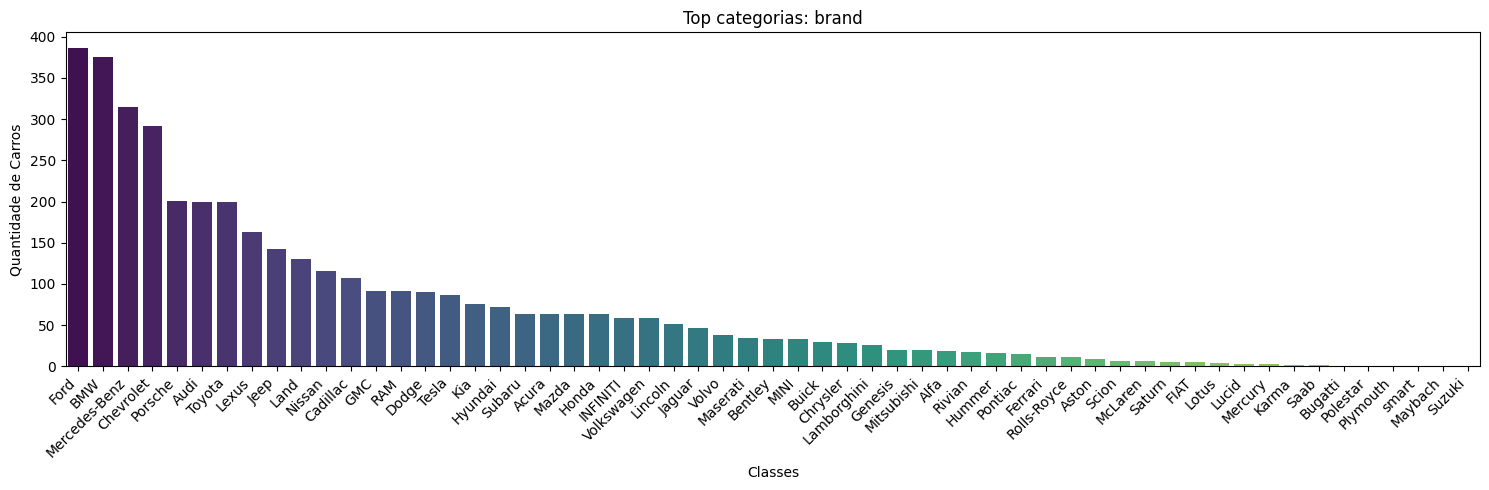

In [2255]:
# Gráfico das categorias mais frequentes da variável brand

grafico_distribuicao(df_cars, 'brand')

Variável *model*:

In [2256]:
# Distribuição de frequencia da variável model

analisar_distribuicao(df_cars, 'model')

--- Análise da Variável: model ---
Total de classes únicas: 1898

                           Frequência Absoluta  Frequência Relativa (%)
model                                                                  
M3 Base                                     30                     0.75
F-150 XLT                                   24                     0.60
Corvette Base                               22                     0.55
1500 Laramie                                18                     0.45
Camaro 2SS                                  17                     0.42
Wrangler Sport                              17                     0.42
Model Y Long Range                          17                     0.42
Mustang GT Premium                          16                     0.40
911 Carrera                                 16                     0.40
M4 Base                                     15                     0.37
911 Carrera S                               14                     0.3

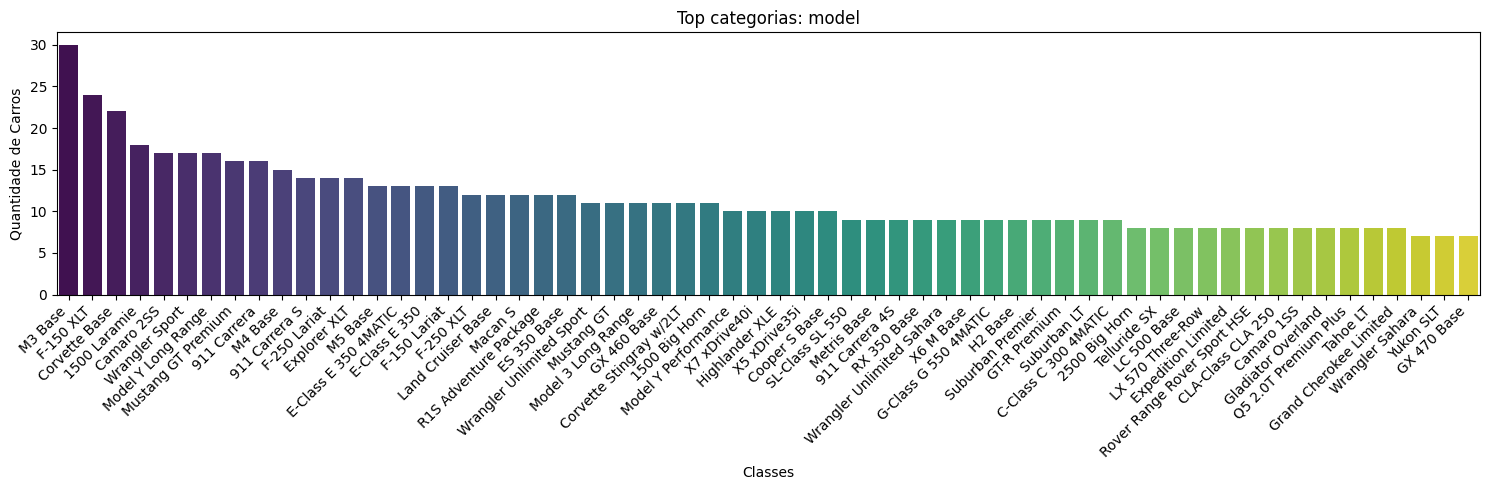

In [2257]:
# Gráfico das categorias mais frequentes da variável model

grafico_distribuicao(df_cars, 'model')

Variável *fuel_type*:

In [2258]:
# Distribuição de frequencia da variável fuel_type

analisar_distribuicao(df_cars, 'fuel_type')

--- Análise da Variável: fuel_type ---
Total de classes únicas: 7

                Frequência Absoluta  Frequência Relativa (%)
fuel_type                                                   
Gasoline                       3309                    86.19
Hybrid                          194                     5.05
E85 Flex Fuel                   139                     3.62
Diesel                          116                     3.02
–                                45                     1.17
Plug-In Hybrid                   34                     0.89
not supported                     2                     0.05


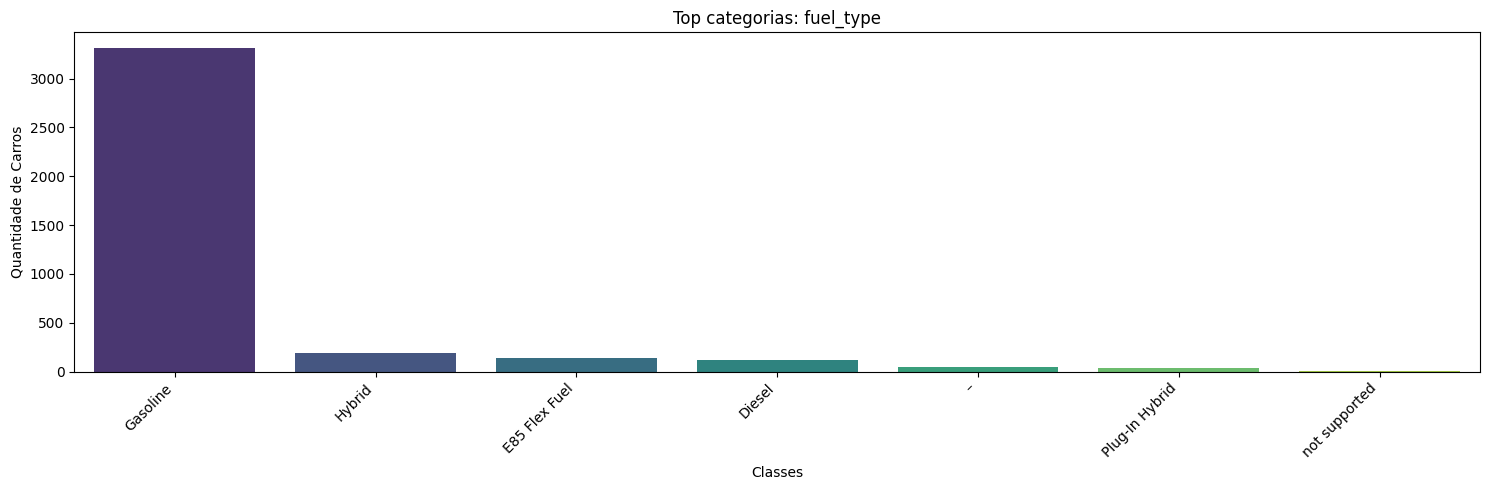

In [2259]:
# Gráfico das categorias mais frequentes da variável fuel_type

grafico_distribuicao(df_cars, 'fuel_type')

Variável *engine*:

In [2260]:
# Distribuição de frequencia da variável engine

analisar_distribuicao(df_cars, 'engine')

--- Análise da Variável: engine ---
Total de classes únicas: 1146

                                                                       Frequência Absoluta  Frequência Relativa (%)
engine                                                                                                             
2.0L I4 16V GDI DOHC Turbo                                                              52                     1.30
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel                                            48                     1.20
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel                                            47                     1.17
–                                                                                       45                     1.12
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel                                   44                     1.10
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel                                            42                     1.05
285.0

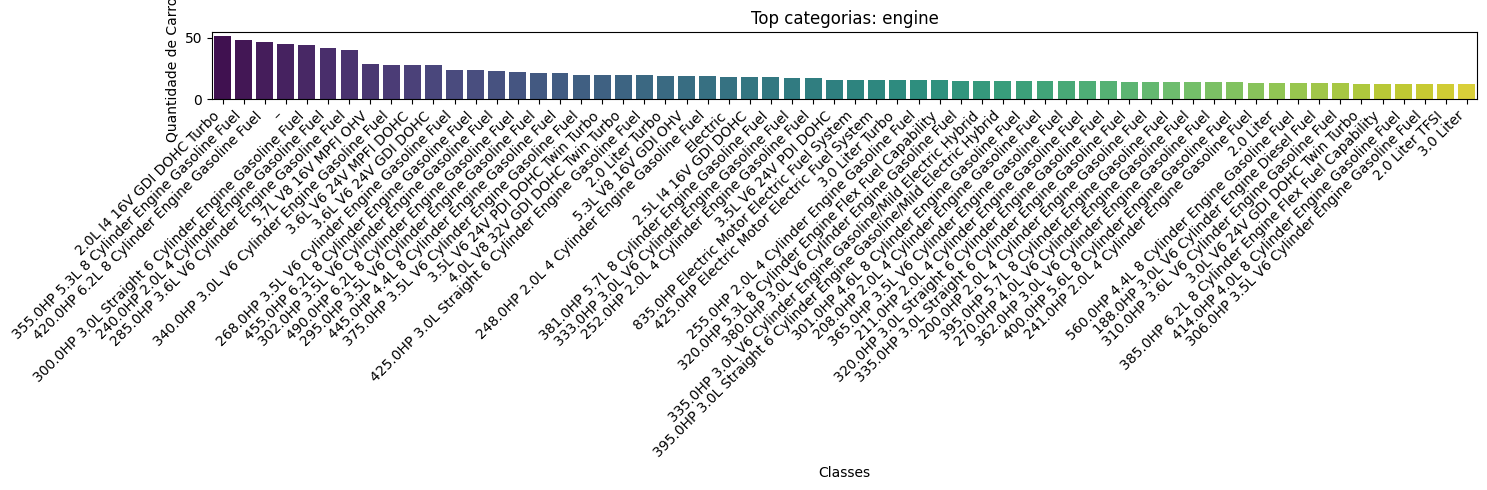

In [2261]:
# Gráfico das categorias mais frequentes da variável engine

grafico_distribuicao(df_cars, 'engine')

Variável *transmission*:

In [2262]:
# Distribuição de frequencia da variável transmission

analisar_distribuicao(df_cars, 'transmission')

--- Análise da Variável: transmission ---
Total de classes únicas: 62

                                                                  Frequência Absoluta  Frequência Relativa (%)
transmission                                                                                                  
A/T                                                                              1037                    25.87
8-Speed A/T                                                                       406                    10.13
Transmission w/Dual Shift Mode                                                    398                     9.93
6-Speed A/T                                                                       362                     9.03
6-Speed M/T                                                                       248                     6.19
Automatic                                                                         237                     5.91
7-Speed A/T                              

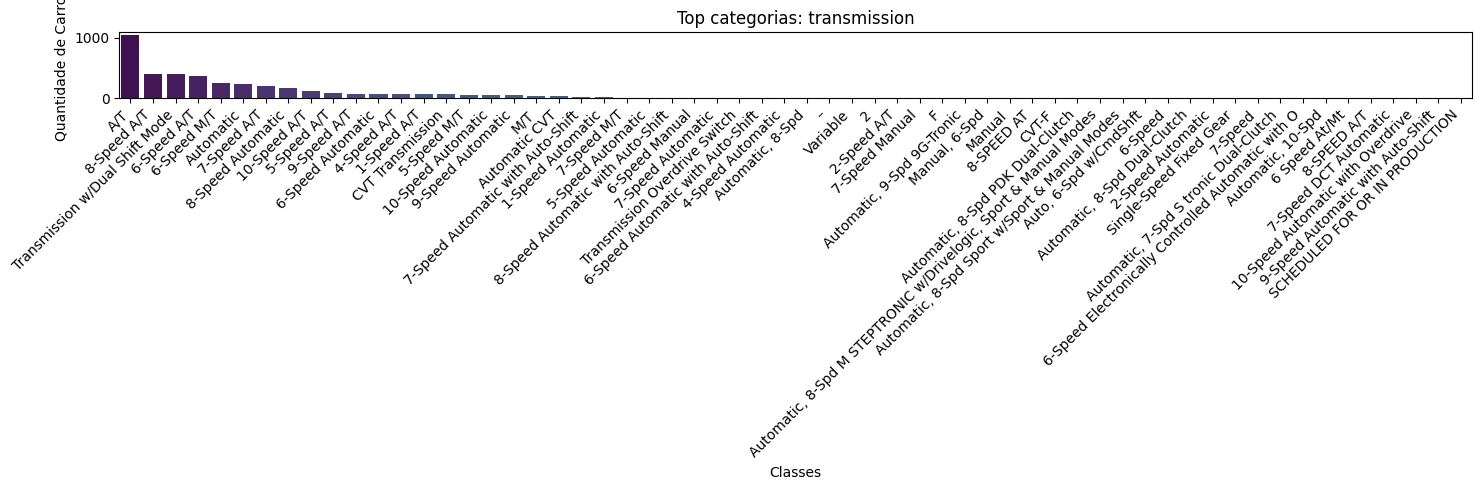

In [2263]:
# Gráfico das categorias mais frequentes da variável transmission

grafico_distribuicao(df_cars, 'transmission')

Variável *ext_col*:

In [2264]:
# Distribuição de frequencia da variável ext_col

analisar_distribuicao(df_cars, 'ext_col')

--- Análise da Variável: ext_col ---
Total de classes únicas: 319

                                    Frequência Absoluta  Frequência Relativa (%)
ext_col                                                                         
Black                                               905                    22.57
White                                               816                    20.35
Gray                                                496                    12.37
Silver                                              374                     9.33
Blue                                                349                     8.71
Red                                                 261                     6.51
Green                                                74                     1.85
Brown                                                43                     1.07
Gold                                                 42                     1.05
Beige                                     

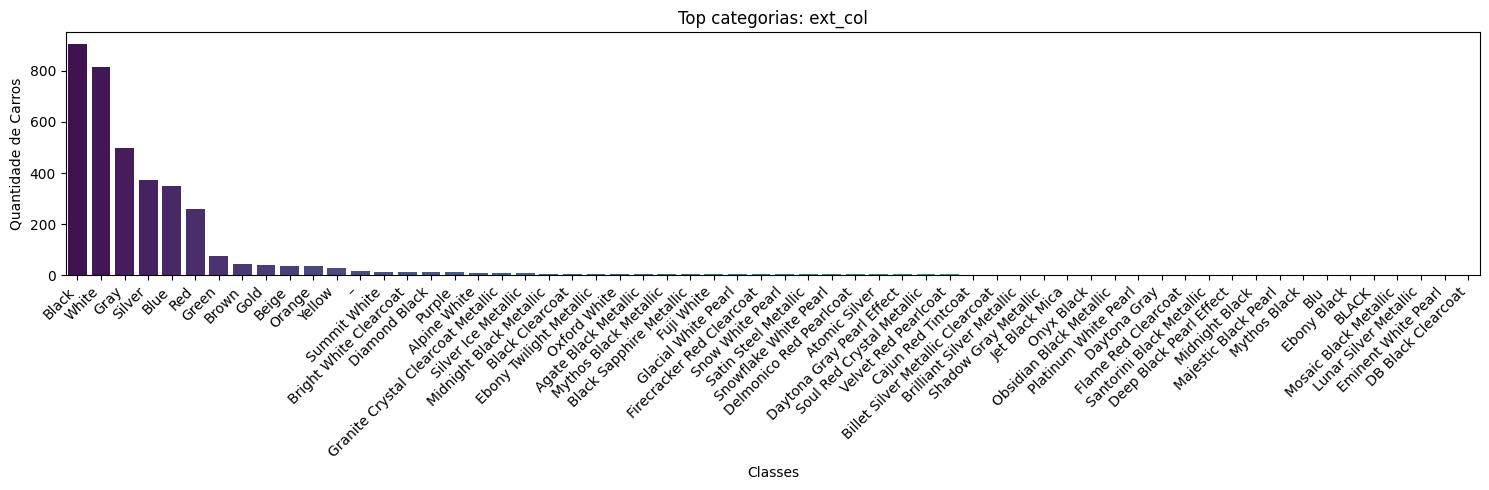

In [2265]:
# Gráfico das categorias mais frequentes da variável ext_col

grafico_distribuicao(df_cars, 'ext_col')

Variável *int_col*:

In [2266]:
# Distribuição de frequencia da variável int_col

analisar_distribuicao(df_cars, 'int_col')

--- Análise da Variável: int_col ---
Total de classes únicas: 156

                       Frequência Absoluta  Frequência Relativa (%)
int_col                                                            
Black                                 2025                    50.51
Beige                                  538                    13.42
Gray                                   472                    11.77
Brown                                  157                     3.92
–                                      133                     3.32
White                                  127                     3.17
Red                                    126                     3.14
Jet Black                               59                     1.47
Ebony                                   44                     1.10
Blue                                    29                     0.72
Orange                                  20                     0.50
Silver                                  16       

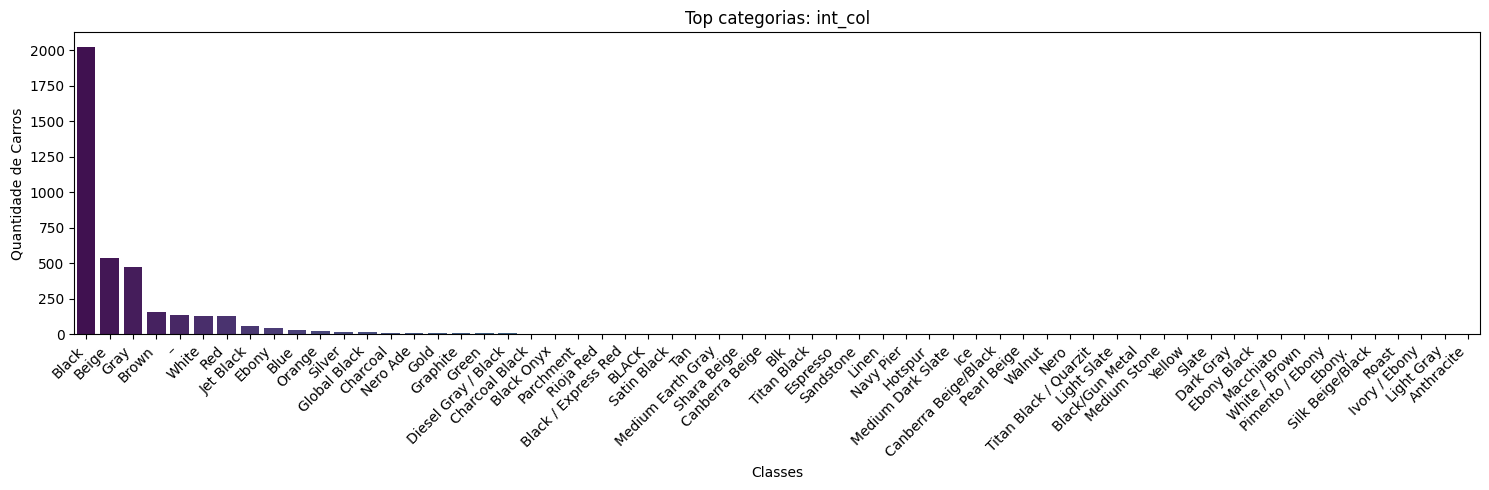

In [2267]:
# Gráfico das categorias mais frequentes da variável int_col

grafico_distribuicao(df_cars, 'int_col')

Variável *accident*:

In [2268]:
# Distribuição de frequencia da variável accident

analisar_distribuicao(df_cars, 'accident')

--- Análise da Variável: accident ---
Total de classes únicas: 2

                                        Frequência Absoluta  Frequência Relativa (%)
accident                                                                            
None reported                                          2910                    74.69
At least 1 accident or damage reported                  986                    25.31


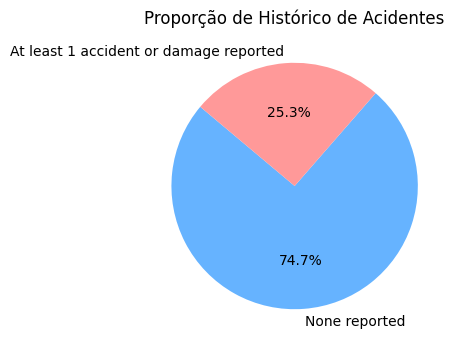

In [2269]:
# Gráfico de pizza das duas categorias da variável accident

import matplotlib.pyplot as plt

# Conta as frequências da coluna accident
dados_accident = df_cars['accident'].value_counts()

# Cria o gráfico de pizza
plt.figure(figsize=(4, 4))

plt.pie(dados_accident,
        labels=dados_accident.index,
        autopct='%1.1f%%', #coloca a porcentagem com uma casa decimal dentro da fatia
        startangle=140,
        colors=['#66b3ff', '#ff9999'])

# Adiciona título
plt.title('Proporção de Histórico de Acidentes')

# Exibe o gráfico
plt.show()

Variável *clean_title*:

In [2270]:
# Distribuição de frequencia da variável clean_title

analisar_distribuicao(df_cars, 'clean_title')

--- Análise da Variável: clean_title ---
Total de classes únicas: 1

             Frequência Absoluta  Frequência Relativa (%)
clean_title                                              
Yes                         3413                    100.0


In [2271]:
# Verificando missing values na coluna clean_title

nulos = df_cars['clean_title'].isnull().sum()
print(f"Total de valores ausentes em clean_title: {nulos}")

Total de valores ausentes em clean_title: 596


### Conclusões da análise das variáveis categóricas:

* As variáveis ***brand, model, engine, transmission, ext_col e int_col*** apresentam uma granularidade excessiva. Esse comportamento exige que, na etapa de Pré-processamento, sejam aplicadas técnicas para reduzir o número de categorias, consolidando classes irrelevantes para evitar o overfitting do modelo.

* Em relação a variável ***fuel_type***, observou-se uma forte concentração de instâncias (86%) na categoria 'Gasoline'. Este desbalanceamento sugere que o modelo terá dificuldade em aprender o comportamento de preços para combustíveis alternativos. Para mitigar esse efeito, buscaremos consolidar as classes minoritárias de forma a melhorar sua representatividade.

* A variável ***accident*** apresenta um comportamento consistente com o esperado, ou seja, a maioria dos veículos anunciados (~75%) não possui histórico de acidentes. Esta variável poderá ser um bom indicador para a depreciação do preço.

* Identificou-se que a coluna ***clean_title*** apresenta uma única classe explícita ("Yes"), enquanto as demais ocorrências constam como valores ausentes. Este comportamento poderia indicar que os campos nulos representam a ausência de um título limpo. Na etapa de tratamento de dados, essa hipótese será avaliada mais a fundo.



## 4.3 Variáveis numéricas

### Estatísticas Descritivas

In [2272]:
# Estatísticas descritivas dos atributos numéricos do dataset

df_cars.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


In [2273]:
# Coeficiente de variação (desvio padrão / média)

# Seleciona colunas numéricas
numericas = df_cars.select_dtypes(include='number')

# Calcula o coeficiente
cv = (numericas.std() / numericas.mean()) * 100
print(cv)


model_year      0.302891
milage         80.807445
price         176.666665
dtype: float64


1. As variáveis ***milage*** e ***price*** têm
média maior que a mediana, caracterizando assimetria à direita (Positiva). Este comportamento indica que estas colunas contêm valores extremos altos (possivelmente outliers), que puxam a média para cima.

    De fato podemos notar, por exemplo, que o carro mais caro da base custa quase 3 milhões de dólares, enquanto a mediana está na casa dos 31 mil dólares.

2. Já a variável ***model_year*** tem o comportamento inverso (assimetria à esquerda), indicando valores extremos mais baixos.

    Este comportamento é realmente o esperado. Dado que a base data de 2023, a maior parte dos carros anunciados foram próximos a essa época, com uma minoria de carros bastante antigos (sendo o mais antigo de 1974!).

3. Analisando o coeficiente de variação, podemos afirmar que a variável *model_year* é uma variável bastante homogênea, ou seja, seu range de valores está bastante próximo da média. Já *milage* e *price* têm coeficiente de dispersão bastante alto, indicando que provavelmente estas classes contém mais outliers e/ou outliers mais extremos.

### Gráficos de barra e histogramas

In [2274]:
# Contagem de categorias da variável model_year, que é numérica discreta

contagem = df_cars['model_year'].nunique()
print(f"model_year: {contagem} categorias \n")

model_year: 34 categorias 



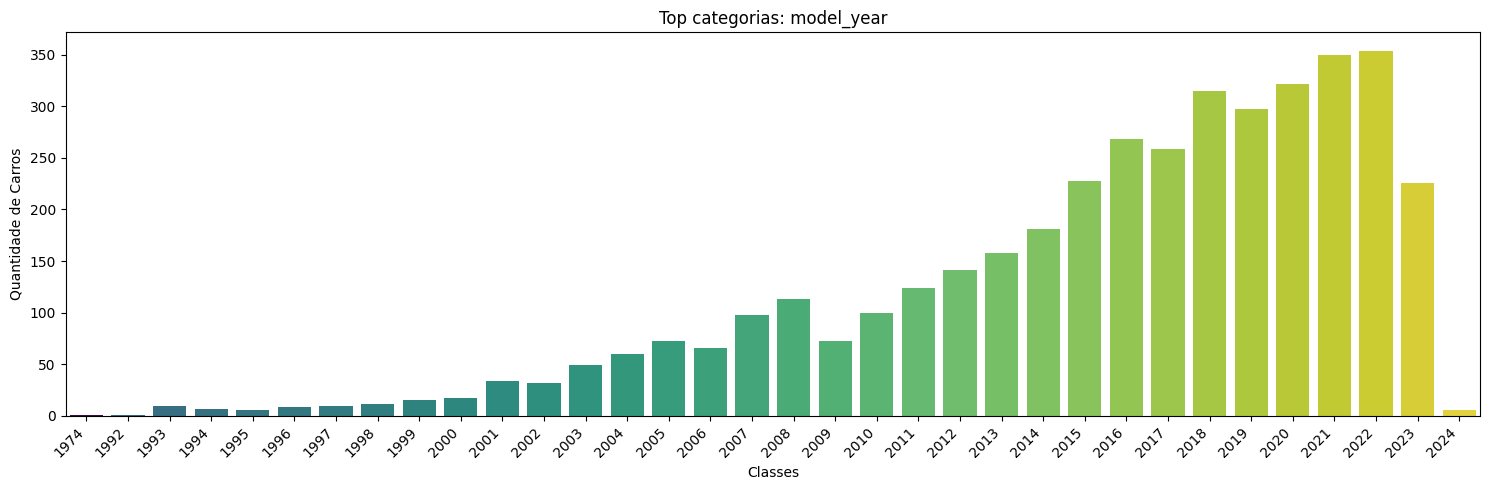

In [2275]:
# Gráfico de barras das categorias da variável model_year

grafico_distribuicao(df_cars, 'model_year')

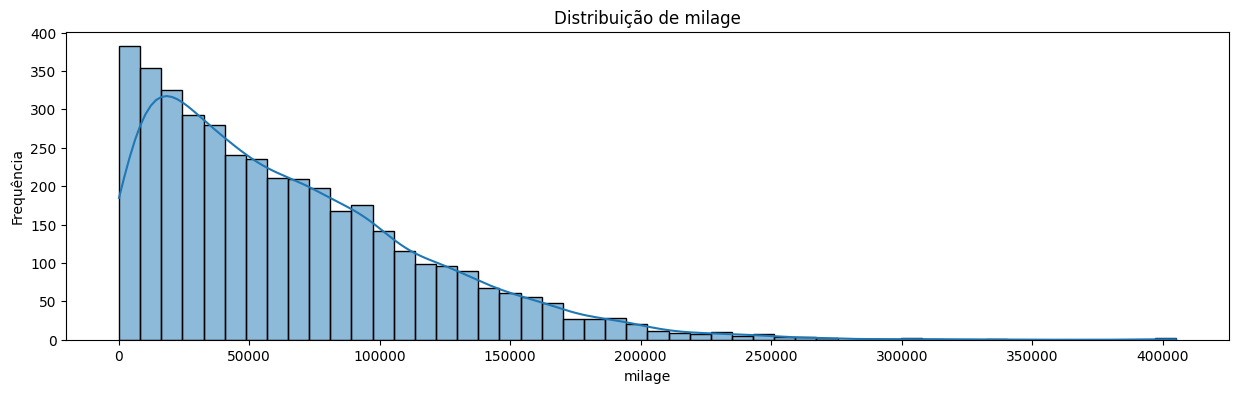

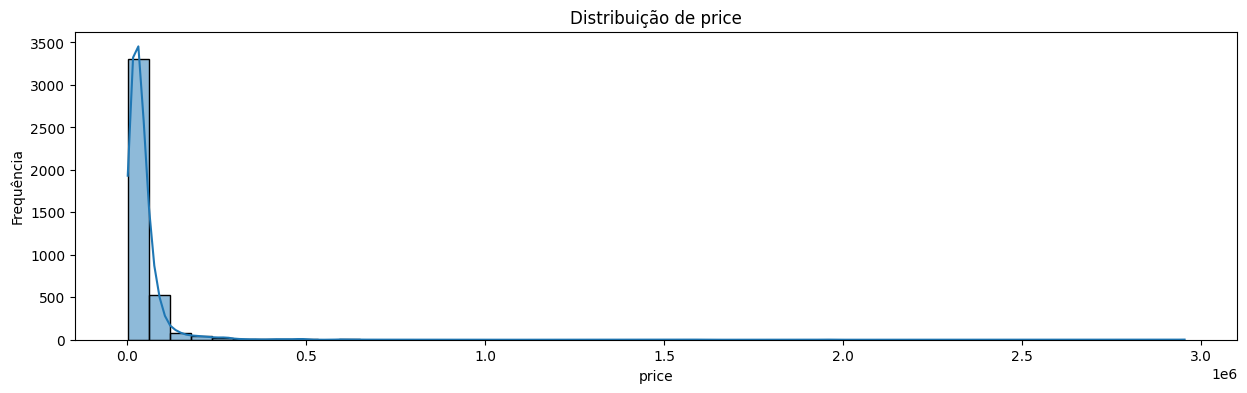

In [2276]:
# Histogramas das variáveis numéricas contínuas do dataset: mileage e price

# Lista das colunas contínuas
colunas_continuas = ['milage', 'price']

# Para cada coluna de variável contínua, plota o histograma
for coluna in colunas_continuas:
    plt.figure(figsize=(15,4))
    sns.histplot(df_cars[coluna], kde=True, bins=50)

    # Insere títulos
    plt.title(f'Distribuição de {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')
    plt.show()

A análise dos histogramas confirma que as variáveis *model_year*, *milage* e *price* são unimodais. Enquanto o ano de fabricação mais frequente (moda) é 2022, as variáveis *milage* e *price* concentram sua massa de dados nos valores iniciais da escala.

Confirmamos visualmente as assimetrias discutidas: *milage* e *price* exibem assimetria positiva (à direita) com caudas longas e ralas, enquanto *model_year* apresenta assimetria negativa (à esquerda), refletindo uma frota predominantemente jovem.

A distribuição de *price* destaca-se pela concentração massiva em valores baixos e uma cauda que se estende até os milhões (segmento de alto luxo). Essa disparidade pode enviesar o modelo, fazendo-o priorizar os outliers e perder precisão no mercado comum. Portanto, será necessário avaliar estratégias para lidar com essa variabilidade, garantindo que os valores extremos não prejudiquem a performance do modelo.

### Gráficos Boxplot

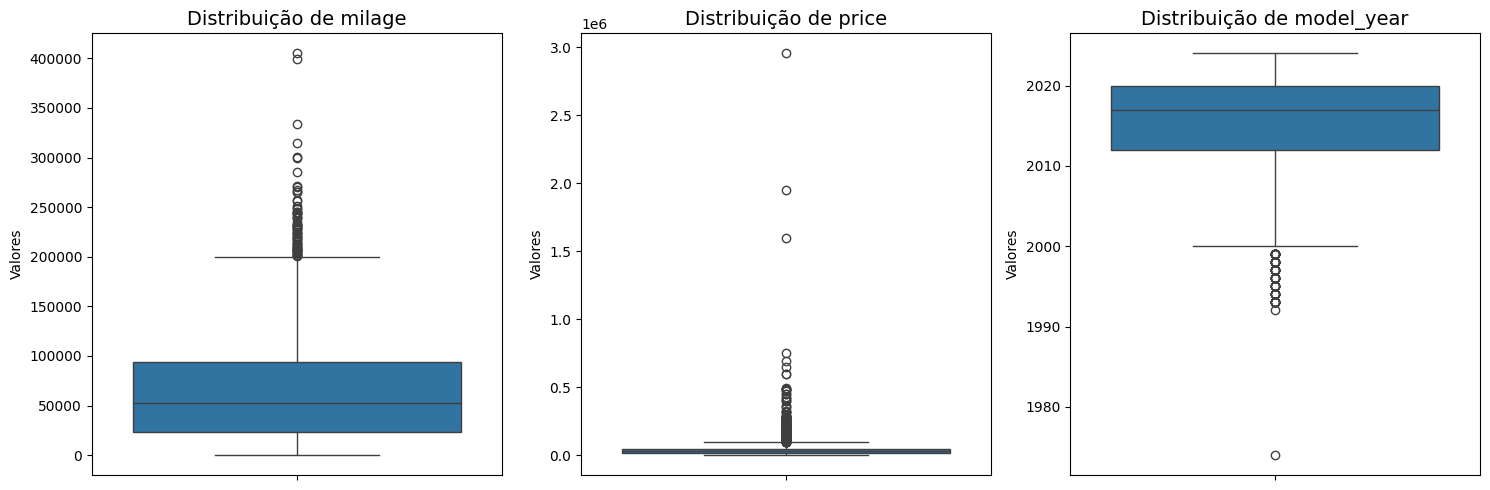

In [2277]:
# Gráficos boxplot das variáveis numéricas do dataset: model_year, mileage e price

# Lista das variáveis numéricas
variaveis = ['milage', 'price', 'model_year']

# Cria uma moldura com 3 colunas para armazenar os 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Para cada variável, desenha o respectivo boxplot e coloca títulos
for i, var in enumerate(variaveis):
    sns.boxplot(y=df_cars[var], ax=axes[i])
    axes[i].set_title(f'Distribuição de {var}', fontsize=14)
    axes[i].set_ylabel('Valores')

# Exibe o gráfico
plt.tight_layout()
plt.show()

A análise visual através dos boxplots, apoiada pelas estatísticas descritivas, revela três comportamentos distintos:

**Preço (*price*)**: É a variável com a maior dispersão e presença de valores extremos. Enquanto 75% da base custa até 49.990 USD, o valor máximo atinge impressionantes 2.95 milhões USD. Essa diferença abissal entre a mediana (31.000 USD) e o máximo indica uma forte assimetria à direita, onde "supercarros" atuam como outliers extremos que podem deslocar a média e impactar a linha de tendência da regressão.

**Quilometragem (*milage*)**: Apresenta uma distribuição mais equilibrada, porém com uma cauda longa. A maioria dos veículos (IQR) situa-se entre 23 mil e 94 mil milhas. Veículos que ultrapassam o limite superior do boxplot (aproximadamente 200 mil milhas) são considerados outliers de uso, chegando ao máximo de 405 mil milhas, refletindo veículos de frota ou de vida útil avançada.

**Ano do Modelo (*model_year*)**: O gráfico mostra uma concentração em veículos recentes, com 50% da base fabricada entre 2012 e 2020. Os outliers aqui são os veículos "vintage" ou antigos: qualquer carro fabricado antes de 2000 é uma exceção estatística, representando uma parcela mínima da base que foge do comportamento de mercado dos seminovos.

### Análise de correlação

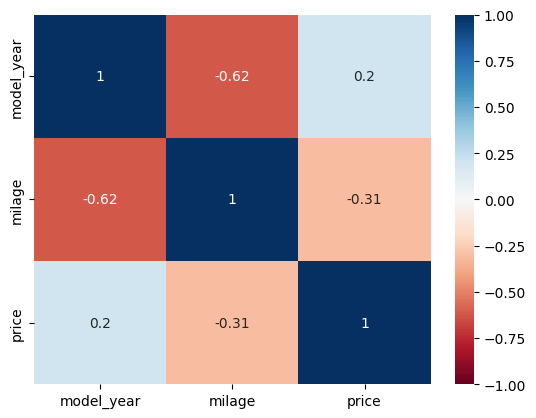

In [2278]:
# Heatmap da correlação de Pearson entre variáveis numéricas

sns.heatmap(df_cars.select_dtypes(include='number').corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1);

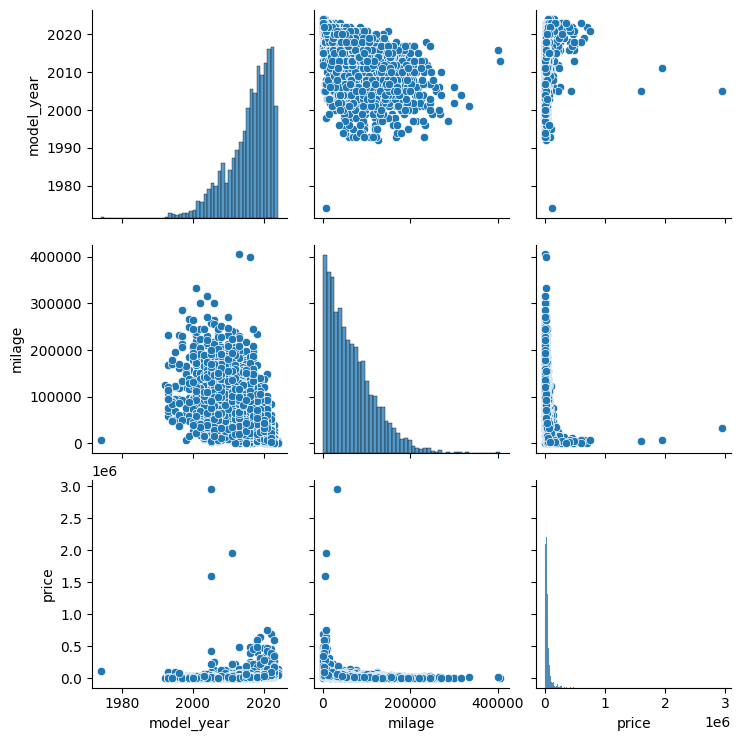

In [2279]:
# Scatterplots e histrogramas das variáveis numéricas do dataframe

sns.pairplot(df_cars);

A análise da matriz de correlação de Pearson revela que não existem associações lineares fortes entre as variáveis numéricas do dataset. A relação mais expressiva ocorre entre *model_year* e *milage* (-0,62), indicando uma correlação negativa moderada, onde veículos mais recentes tendem a apresentar menor quilometragem, conforme esperado.

Entretanto, as correlações envolvendo a variável alvo *price* são fracas sugerindo que o preço não é determinado de forma isolada por nenhum desses fatores de maneira linear.

Os gráficos de dispersão (scatterplots) reforçam essa interpretação, apresentando distribuições sem tendências direcionais nítidas. Observa-se que veículos com preços baixos e altos coexistem em praticamente todos os anos de fabricação e faixas de rodagem.

Esses resultados indicam que o preço dos automóveis é um fenômeno multivariado e complexo, onde atributos categóricos de alta cardinalidade — como marca e modelo — provavelmente exercem maior influência do que as variáveis numéricas isoladas. Conclui-se que a análise de correlação poderá ser mais elucidativa após a etapa de Engenharia de Atributos, quando a segmentação por nichos (como veículos de luxo e populares) permitir que padrões específicos emerjam de forma mais clara dentro de cada grupo.

# 5. Pré-processamento

### Resumo dos Dataframes do Projeto

A tabela abaixo descreve a evolução dos dados ao longo das etapas de tratamento, servindo como guia para as análises apresentadas neste capítulo e no próximo.

| Dataframe | Descrição e Estágio do Tratamento | Principais Transformações |
| :--- | :--- | :--- |
| **`df_cars`** | **Dataset Processado:** Base original enriquecida com lógica de negócio e novas variáveis. | 1. Conversão de tipos (texto para numérico).<br>2. Tratamento de *missings*.<br>3. Criação de variáveis estruturadas: `brand_tier`, `model_persona`, `fuel_group`, `engine_config`, `engine_hp`, `engine_displacement`, `is_turbo`, `transmission_grouped`, `ext_col_group`, `int_col_group`, `vehicle_age`. |
| **`df_cars_clean`** | **Dataset Higienizado:** Base refinada para análise estatística e validação de hipóteses. | 1. Remoção de *outliers* globais (`milage` e `vehicle_age`).<br>2. Remoção de *outliers* segmentados por nicho (`price`).<br>3. Seleção de atributos de interesse para as análises finais. |
| **`df_cars_final`** | **Dataset de Modelagem:** Base final preparada matematicamente para algoritmos de regressão. | 1. Aplicação de *Dummy Encoding* nas variáveis categóricas.<br>2. Normalização (*MinMaxScaler*) das variáveis numéricas preditoras. |
| **`df_top_segmentos`** | **Dataset de Validação:** Recorte estatístico dos segmentos majoritários do mercado. | 1. Filtragem dos 5 segmentos com maior representatividade (79% da base).<br>2. Base utilizada para mitigar ruídos de nichos em análises estratificadas. |

## 5.1 Limpeza: Tratamento de missings

Neste capítulo, realizaremos o tratamento de dados ausentes (missing values), uma etapa vital, pois a maioria dos algoritmos de Machine Learning é incapaz de processar registros incompletos, o que causaria erros fatais durante o treinamento.

A correta manipulação dessas lacunas evita a perda de informações valiosas e impede que o modelo aprenda padrões distorcidos.

Podemos verificar abaixo que apenas as colunas *fuel_type*, *accident* e *clean_title* contêm valores nulos:

In [2280]:
# Identificando quantos missings existem em cada coluna

df_cars.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


### Missings de *fuel_type*:

In [2281]:
# Filtrando missings da coluna fuel_type

missings = df_cars[df_cars['fuel_type'].isnull()]

print(missings.head(10).to_string())

# Para fins de relatório exibimos apenas 10 registros,
# mas a análise qualitativa foi feita em cima do conjunto completo de 170 registros

        brand                    model  model_year   milage fuel_type                                       engine       transmission       ext_col   int_col       accident clean_title     price
9       Tesla  Model X Long Range Plus        2020  34000.0       NaN  534.0HP Electric Motor Electric Fuel System                A/T         Black     Black  None reported         Yes   69950.0
44      Lucid        Air Grand Touring        2022   3552.0       NaN  536.0HP Electric Motor Electric Fuel System        1-Speed A/T           Red     Beige  None reported         Yes  119999.0
68      Lucid        Air Grand Touring        2022   4900.0       NaN  536.0HP Electric Motor Electric Fuel System        1-Speed A/T           Red     Black  None reported         Yes   99000.0
92     Rivian    R1S Adventure Package        2023   2800.0       NaN  835.0HP Electric Motor Electric Fuel System        1-Speed A/T         White     Green  None reported         Yes   92000.0
122    Rivian    R1S Adve

Observando as instâncias em que o *fuel_type* aparece nulo, identificamos por meio da coluna *engine* que se tratam de modelos de carros elétricos.

A partir desta conclusão, justifica-se transformar os valores missing desta coluna em 'Electric', garantindo que esses veículos sejam classificados corretamente e contribuam para a performance do modelo.

In [2282]:
# Transformando missing de fuel_type em 'Electric'

df_cars['fuel_type'] = df_cars['fuel_type'].fillna('Electric')

Posteriormente, na etapa de Feature Engineering, prosseguiremos com a reestruturação desta coluna.

### Missings de *accident*:

In [2283]:
# Filtrando missings da coluna accident

missings = df_cars[df_cars['accident'].isnull()]

print(missings.head(10).to_string())

# Para fins de relatório exibimos apenas 10 registros,
# mas a análise qualitativa foi feita em cima do conjunto completo de 113 registros

             brand                    model  model_year    milage fuel_type                                             engine                    transmission       ext_col int_col accident clean_title    price
20         Genesis          GV70 3.5T Sport        2023    5400.0  Gasoline      375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel                     8-Speed A/T         Green   Beige      NaN         NaN  60000.0
89          Subaru           Forester 2.5 X        2004  210703.0  Gasoline       165.0HP 2.5L 4 Cylinder Engine Gasoline Fuel                             M/T         Green   Beige      NaN         NaN   2300.0
128           Audi     Q7 3.0T Premium Plus        2015   98527.0  Gasoline      280.0HP 3.0L V6 Cylinder Engine Gasoline Fuel                     8-Speed A/T         Black   Black      NaN         NaN   9995.0
129          Lucid                 Air Pure        2023    1300.0  Electric        620.0HP Electric Motor Electric Fuel System                             A

In [2284]:
# Calculando estatísticas descritivas de preço das classes de accident

# Calcula métricas por classe
resultado = df_cars.groupby('accident', dropna=False)['price'].agg(['mean', 'median', 'count','std','min','max'])

# Exibe o resultado
print(resultado.to_string())

                                                mean   median  count           std     min        max
accident                                                                                             
At least 1 accident or damage reported  28831.500000  20900.0    986  95401.765975  2300.0  2954083.0
None reported                           49638.073196  35667.5   2910  72554.118094  2000.0  1950995.0
NaN                                     50788.389381  36500.0    113  45260.414855  2300.0   244896.0


Conforme a análise das variáveis categóricas, cerca de 75% do dataset apresenta o valor 'None reported' na coluna *accident*, sendo esta a moda da variável.

Adicionalmente, observamos que a média e a mediana de preço para os valores nulos (NaN) estão muito próximas dos valores da classe 'None reported', enquanto a categoria com acidentes registrados apresenta um comportamento de preço nitidamente inferior e distinto.

Essas observações confirmam que os registros nulos se comportam financeiramente como veículos sem acidentes, justificando a decisão de preenchê-los com o valor 'None reported'.

In [2285]:
# Transformando missings de accident em 'None reported'

df_cars['accident'] = df_cars['accident'].fillna('None reported')

In [2286]:
# Distribuição de frequencia da variável accident

analisar_distribuicao(df_cars, 'accident')

--- Análise da Variável: accident ---
Total de classes únicas: 2

                                        Frequência Absoluta  Frequência Relativa (%)
accident                                                                            
None reported                                          3023                    75.41
At least 1 accident or damage reported                  986                    24.59


In [2287]:
# Definindo função que cria gráfico boxplot dos preços de veículos, nas classes da variável escolhida

def boxplot_price (df, coluna_x):
    # Cria espaço para o gráfico
    plt.figure(figsize=(9, 5))

    # Cria o gráfico Boxplot
    sns.boxplot(x=coluna_x, y='price', data=df,
                palette='viridis',
                hue=coluna_x,
                legend=False)

    # Ajusta a escala
    plt.yscale('log') # Escala logarítmica para lidar com outliers extremos

    # Inclui os títulos
    plt.title(f'Distribuição de Preços por {coluna_x} (Escala Log)', fontsize=14)
    plt.xlabel(f'{coluna_x}', fontsize=12)
    plt.ylabel('Preço ($)', fontsize=12)


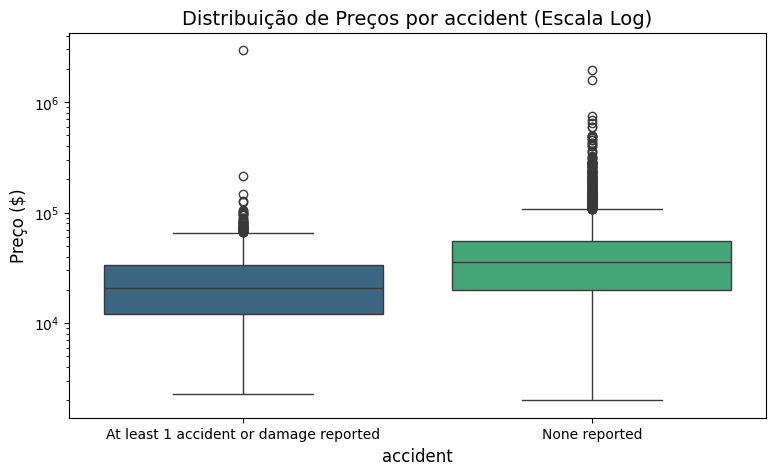

In [2288]:
# Criando boxplot dos preços de veículos, nas classes da variável accident

boxplot_price(df_cars, 'accident')

Como ilustrado no boxplot acima, a mediana de preço é superior para veículos sem histórico de acidentes. Este comportamento será reavaliado de forma mais criteriosa após o tratamento de outliers, etapa essencial para isolar distorções e verificar, de maneira mais assertiva, como o histórico de danos impacta o valor de mercado dos veículos.

### Missings de *clean_title*:

Conforme identificado na análise exploratória inicial, a coluna *clean_title* apresenta apenas a classe explícita 'Yes', com as demais ocorrências registradas como valores nulos.

Partimos da hipótese de que essa estrutura por omissão indica a ausência de um título limpo. Para testar essa premissa, realizaremos a binarização do atributo, convertendo os valores nulos em 'No', e avaliaremos se a relação resultante com a variável alvo (*price*) é consistente com a lógica de negócio.

In [2289]:
# Tranformando missings de clean_title em 'No'

df_cars['clean_title'] = df_cars['clean_title'].fillna('No')

In [2290]:
# Analisa estatísticas descritivas de preço nos novos grupos

comparativo_precos = df_cars.groupby('clean_title')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)

                     mean   median  count           std     min        max
clean_title                                                               
No           60695.077181  42996.5    596  57982.778955  2300.0   449991.0
Yes          41734.390272  29000.0   3413  81472.770029  2000.0  2954083.0


A variável *clean_title* tem como função atestar a disponibilidade de um título sem pendências legais ou sinistros graves, um atributo que, teoricamente, deveria valorizar o veículo e oferecer maior segurança ao comprador. Com base nessa premissa, partimos da hipótese de que a binarização interpretativa (nulo = 'No') resultaria em uma mediana de preços inferior para o grupo sem a confirmação do título limpo.

Contudo, a análise estatística refutou essa expectativa: o grupo 'No' apresentou uma mediana de 42.996 USD, significativamente superior aos 29.000 USD do grupo 'Yes'. Esse comportamento contradiz a lógica de mercado e demonstra que não há uma interpretação semântica confiável para os 15% da base que não possuem essa informação preenchida.

Somado à inconsistência, o fato de o atributo apresentar baixa variância (com 85% da base concentrada em uma única classe) compromete sua força de predição. Sem uma justificativa lógica para o comportamento dos dados omissos e para evitar a introdução de ruídos no algoritmo, optou-se pelo descarte da variável *clean_title*.

In [2291]:
# Eliminando o atributo clean_title

df_cars = df_cars.drop(columns=['clean_title'])

### Checagem das transformações realizadas

In [2292]:
# Checagem de missings
df_cars.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


O dataframe em estudo já não apresenta entradas nulas.

## 5.2 Feature Engineering

Nesta etapa, transformaremos os dados brutos em formatos que otimizem o aprendizado do modelo. Identificamos que as variáveis *brand, model, engine, transmission, ext_col* e *int_col* apresentam uma granularidade excessiva (alta cardinalidade). Esse comportamento exige a aplicação de técnicas para reduzir o número de categorias, consolidando classes com baixa representatividade para evitar o overfitting e garantir que o modelo aprenda padrões gerais em vez de decorar ruídos.

Além disso, a variável *fuel_type* apresenta um forte desbalanceamento, com 86% das instâncias concentradas na categoria 'Gasoline'. Esse cenário sugere que o algoritmo terá dificuldade em prever preços para veículos com combustíveis alternativos. Para mitigar esse efeito e melhorar a performance preditiva, buscaremos agrupar as classes minoritárias, melhorando a representatividade desses grupos.

**Nota:** Para fins de relatório, exibimos apenas as 50 classes mais frequentes de cada variável. Contudo, todas as categorias foram integralmente consideradas para o planejamento e execução do tratamento de cada atributo.

### Marca (*brand*)

In [2293]:
# Distribuição de frequencia da variável brand

analisar_distribuicao(df_cars, 'brand')

--- Análise da Variável: brand ---
Total de classes únicas: 57

               Frequência Absoluta  Frequência Relativa (%)
brand                                                      
Ford                           386                     9.63
BMW                            375                     9.35
Mercedes-Benz                  315                     7.86
Chevrolet                      292                     7.28
Porsche                        201                     5.01
Audi                           200                     4.99
Toyota                         199                     4.96
Lexus                          163                     4.07
Jeep                           143                     3.57
Land                           130                     3.24
Nissan                         116                     2.89
Cadillac                       107                     2.67
GMC                             91                     2.27
RAM                             91  

Para otimizar a performance do modelo de regressão e mitigar o problema da alta cardinalidade (57 marcas para 4.009 registros), consolidamos a variável *brand* em três categorias estratégicas. Esta segmentação baseia-se no conhecimento de domínio do mercado automobilístico, agrupando fabricantes pelo seu posicionamento de preço, prestígio e proposta de valor.

As novas *brand_tiers* são definidas da seguinte forma:

**Luxury & Exotic**: Composta por marcas de nicho, supercarros e alto luxo (ex: Ferrari, Porsche, Lamborghini). Representa veículos com baixa depreciação e preços regidos por exclusividade e performance de ponta.

**Premium**: Inclui marcas de luxo consolidadas e modelos executivos (ex: BMW, Mercedes-Benz, Tesla, Audi). Representa o segmento de alto valor agregado e tecnologia superior, mas com maior volume de mercado que a categoria anterior.

**Mainstream & Others**: Agrupa marcas de volume e fabricantes generalistas (ex: Toyota, Ford, Chevrolet, Honda). Representa o mercado de massa, focado em utilidade e escala, onde os preços tendem a ser mais sensíveis à depreciação e quilometragem.

In [2294]:
# Criando tiers de marcas, baseados em conhecimento de negócio

brand_tiers = {
    # LUXURY & EXOTIC
    'Porsche': 'Luxury_Exotic', 'Lamborghini': 'Luxury_Exotic', 'Ferrari': 'Luxury_Exotic',
    'Rolls-Royce': 'Luxury_Exotic', 'Aston': 'Luxury_Exotic', 'Bentley': 'Luxury_Exotic',
    'McLaren': 'Luxury_Exotic', 'Bugatti': 'Luxury_Exotic', 'Lotus': 'Luxury_Exotic',
    'Maybach': 'Luxury_Exotic', 'Maserati': 'Luxury_Exotic', 'Lucid': 'Luxury_Exotic',
    'Rivian': 'Luxury_Exotic', 'Land': 'Luxury_Exotic',

    # PREMIUM
    'BMW': 'Premium', 'Mercedes-Benz': 'Premium', 'Audi': 'Premium',
    'Lexus': 'Premium', 'Tesla': 'Premium', 'Cadillac': 'Premium',
    'Jaguar': 'Premium', 'Genesis': 'Premium', 'Alfa': 'Premium',
    'Volvo': 'Premium', 'INFINITI': 'Premium', 'Acura': 'Premium',
    'Lincoln': 'Premium', 'Polestar': 'Premium', 'Karma': 'Premium',

    # MAINSTREAM & OTHERS
    'Ford': 'Mainstream', 'Chevrolet': 'Mainstream', 'Toyota': 'Mainstream',
    'Jeep': 'Mainstream', 'Nissan': 'Mainstream', 'RAM': 'Mainstream',
    'GMC': 'Mainstream', 'Dodge': 'Mainstream', 'Kia': 'Mainstream',
    'Hyundai': 'Mainstream', 'Subaru': 'Mainstream', 'Mazda': 'Mainstream',
    'Honda': 'Mainstream', 'Volkswagen': 'Mainstream', 'Chrysler': 'Mainstream',
    'Buick': 'Mainstream', 'MINI': 'Mainstream', 'Mitsubishi': 'Mainstream',
    'Pontiac': 'Mainstream', 'Hummer': 'Mainstream', 'Scion': 'Mainstream',
    'Saturn': 'Mainstream', 'FIAT': 'Mainstream', 'Mercury': 'Mainstream',
    'Saab': 'Mainstream', 'Suzuki': 'Mainstream', 'smart': 'Mainstream',
    'Plymouth': 'Mainstream'
}

# Criando a nova feature
df_cars['brand_tier'] = df_cars['brand'].map(brand_tiers)

# Verifica estatísticas dos novos grupos
comparativo_precos = df_cars.groupby('brand_tier')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)



                        mean   median  count            std     min        max
brand_tier                                                                    
Luxury_Exotic  113580.295082  67997.5    488  197473.376275  5750.0  2954083.0
Mainstream      30447.236308  26500.0   1972   25066.177892  2300.0   489995.0
Premium         40764.755326  32000.0   1549   34680.915463  2000.0   479995.0


In [2295]:
# Distribuição de frequencia da variável brand_tier

analisar_distribuicao(df_cars, 'brand_tier')

--- Análise da Variável: brand_tier ---
Total de classes únicas: 3

               Frequência Absoluta  Frequência Relativa (%)
brand_tier                                                 
Mainstream                    1972                    49.19
Premium                       1549                    38.64
Luxury_Exotic                  488                    12.17


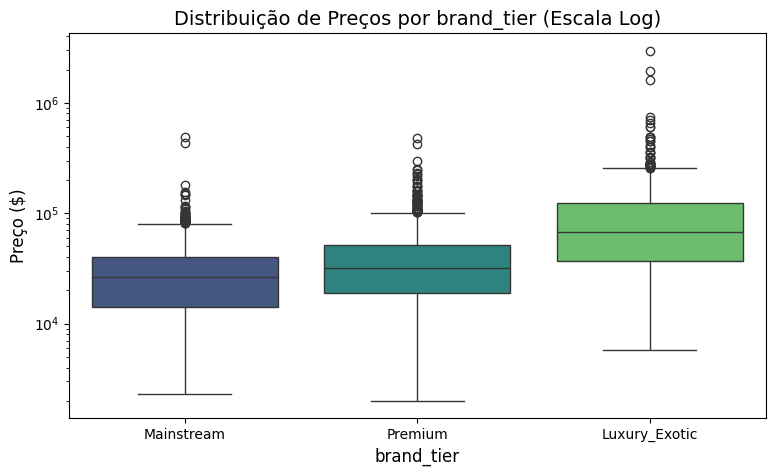

In [2296]:
# Criando boxplot dos preços de veículos, nas classes da variável brand_tier

boxplot_price(df_cars, 'brand_tier')

O boxplot ratifica a eficácia da segmentação: o grupo **Luxury & Exotic** apresenta a maior mediana e os valores mais elevados, confirmando o prêmio por exclusividade e performance. O tier **Premium** demonstra um patamar de preço superior a mediana geral, com dispersão moderada, enquanto o **Mainstream & Others** concentra a maior volumetria com a menor mediana, refletindo o mercado de massa. Essa distinção de patamares financeiros valida o uso dos tiers como preditores para o modelo.

### Modelo (*model*)

In [2297]:
# Distribuição de frequencia da variável model

analisar_distribuicao(df_cars, 'model')

--- Análise da Variável: model ---
Total de classes únicas: 1898

                           Frequência Absoluta  Frequência Relativa (%)
model                                                                  
M3 Base                                     30                     0.75
F-150 XLT                                   24                     0.60
Corvette Base                               22                     0.55
1500 Laramie                                18                     0.45
Camaro 2SS                                  17                     0.42
Wrangler Sport                              17                     0.42
Model Y Long Range                          17                     0.42
Mustang GT Premium                          16                     0.40
911 Carrera                                 16                     0.40
M4 Base                                     15                     0.37
911 Carrera S                               14                     0.3

Para resolver o desafio de ter 1.898 modelos diferentes, aplicamos uma estratégia baseada na realidade do mercado automotivo. Em vez de tratar cada nome de carro como um texto isolado, agrupamos os veículos pelo seu perfil de entrega: o que eles oferecem ao comprador e para qual objetivo foram desenhados.

**High_Performance (Esportivos e Ícones)**: Carros feitos para quem busca velocidade, potência e status de pista (ex: Porsche 911, modelos M ou RS). O valor aqui está na engenharia e no prazer de dirigir.

**Heavy_Duty_Utility (Carga e Aventura)**: Picapes e utilitários robustos feitos para trabalho pesado ou trilhas (ex: RAM 2500, Ford F-150, Jeep Wrangler). O valor está na capacidade de carga, tração e resistência.

**Luxury_Premium (Luxo e Conforto)**: SUVs e sedans espaçosos, focados em famílias que buscam o máximo de itens tecnológicos e acabamento refinado (ex: Cadillac Escalade, BMW X7). O valor está no conforto e na representação de status.

**Daily_Standard (Uso Diário):** Carros práticos para o dia a dia, como ir ao trabalho ou levar as crianças à escola (ex: Toyota Corolla, Honda CR-V). O valor aqui é regido pela economia, durabilidade e custo-benefício.

In [2298]:
# Definindo as 4 novas classes (model_persona), baseadas nos modelos dos veículos

def classify_model_persona(model_name):
    m = " " + str(model_name).upper().strip() + " "
# Colocar o espaço antes e depois do model_name serve para achar as pequenas strings corretamente mais a frente,
# porque elas estão com espaço nas listas para evitar que encontremos o pedaço de uma outra palavra

    # Define modelos classificados como High Performance
    perf_terms = [
        'MUSTANG GT', 'FORD GT', 'CARRERA GT', ' AMG ', ' M2 ', ' M3 ', ' M4 ', ' M5 ',
        ' M6 ', ' M8 ', ' RS3 ', ' RS4 ', ' RS5 ', ' RS6 ', ' RS7 ', 'SQ5', 'SQ7', 'SQ8',
        ' S4 ', ' S5 ', ' S6 ', ' S8 ', ' DBS ', 'F12BERLINETTA', 'GTC4LUSSO', ' FF ',
        ' TRX ', ' RAPTOR ', 'Z06', 'ZL1', 'SHELBY', 'GT500', 'GT3', 'GT4', 'SPYDER',
        'HELLCAT', 'TURBO S', ' 911 ', 'CORVETTE', 'AVENTADOR', 'HURACAN', 'URUS',
        'FERRARI', ' R8 ', 'NSX', 'VIPER', 'LC 500', 'SUPRA', ' I8 ', 'VEYRON',
        'GALLARDO', 'MURCIELAGO', ' 488 ', ' F430 ', ' ROMA ', ' 812 ', ' 720S ',
        ' 570S ', 'F-TYPE', 'BLACKWING', 'GT-R', 'Z PROTO', 'BOXSTER', 'CAYMAN',
        'CTS-V', ' Z4 ', 'MACH-E GT', 'QUADRIFOGLIO', 'GOLF R', 'GR COROLLA',
        'GR86', 'STINGER', 'BOSS 302', ' SCAT PACK ', ' SVR ', 'MC20', 'TYPE S',
        'EVO ', 'EVOLUTION', 'EVORA', 'S2000'
    ]

    # Define modelos classificados como Heavy Duty Utility
    util_terms = [
        'F-150', 'F-250', 'F-350', 'F-450', 'SILVERADO', 'SIERRA', 'TUNDRA', 'TACOMA',
        'NISSAN TITAN', ' RAM ', '1500', '2500', '3500', 'WRANGLER', 'GLADIATOR',
        'DEFENDER', 'BRONCO BADLANDS', 'BRONCO WILDTRAK', 'BRONCO RAPTOR', 'BRONCO HERITAGE',
        'BRONCO XLT', 'BRONCO BLACK DIAMOND', 'BRONCO OUTER BANKS', 'HUMMER', ' R1T ', ' R1S ',
        'TRD PRO', 'SAVANA', 'PROMASTER', 'CHEYENNE', 'AVALANCHE', 'EXPRESS 1500',
        'EXPRESS 2500', 'EXPRESS 3500'
    ]

    # Define modelos classificados como Luxury & Premium
    luxury_terms = [
        'ESCALADE', 'NAVIGATOR', 'RANGE ROVER', 'EVOQUE', 'VELAR', 'BENTAYGA',
        'CULLINAN', 'PHANTOM', 'GHOST', 'WRAITH', 'CONTINENTAL', 'FLYING SPUR',
        'MAYBACH', 'ALPINA', 'LUCID', ' TAYCAN ', ' PANAMERA ', 'MODEL S',
        'MODEL X', 'MODEL Y', 'MODEL 3', 'S-CLASS', 'E-CLASS', 'G-CLASS',
        'SL-CLASS', 'CLS-CLASS', ' GLE 3', ' GLE 4', ' GLE 5', ' GLS 4', ' GLS 5',
        ' GLS 6', ' GLC ', ' GLB ', ' 750', ' 840', ' 850', ' A8 ', ' A7 ',
        'LS 500', 'GX 460', 'LX 570', 'LX 600', 'RX 450', 'QX80', 'QX60', 'REVERO',
        'QUATTROPORTE', 'GHIBLI', 'WAGONEER', 'EXPEDITION', 'SEQUOIA', 'LAND CRUISER',
        'SUBURBAN', 'TAHOE', 'YUKON', 'TELLURIDE', 'PALISADE', 'SIENNA', 'RDX',
        'MDX', 'E-TRON', 'LYRIQ', 'CX-90', 'RX 350', 'NX 350', 'CALIFORNIA T',
        'METRIS', 'SPRINTER'
    ]

    # Retorno baseado na avaliação das listas
    return (
        'High_Performance' if any(x in m for x in perf_terms) else
        'Heavy_Duty_Utility' if any(x in m for x in util_terms) else
        'Luxury_Premium' if any(x in m for x in luxury_terms) else
        'Daily_Standard'
    )

# Aplica função ao dataset em estudo
df_cars['model_persona'] = df_cars['model'].apply(classify_model_persona)

# Verifica estatísticas dos novos grupos
comparativo_precos = df_cars.groupby('model_persona')['price'].agg(['mean', 'median', 'count', 'std','min', 'max'])
print(comparativo_precos.to_string())

                            mean   median  count            std     min        max
model_persona                                                                     
Daily_Standard      25955.519843  21495.0   2041   21580.995493  2000.0   429998.0
Heavy_Duty_Utility  40583.799625  39200.0    534   23447.046297  3000.0   200000.0
High_Performance    88612.014331  60350.0    628  126414.133444  3900.0  1950995.0
Luxury_Premium      59948.424318  43549.5    806  119229.710964  3950.0  2954083.0


In [2299]:
# Distribuição de frequencia da variável model_persona

analisar_distribuicao(df_cars, 'model_persona')

--- Análise da Variável: model_persona ---
Total de classes únicas: 4

                    Frequência Absoluta  Frequência Relativa (%)
model_persona                                                   
Daily_Standard                     2041                    50.91
Luxury_Premium                      806                    20.10
High_Performance                    628                    15.66
Heavy_Duty_Utility                  534                    13.32


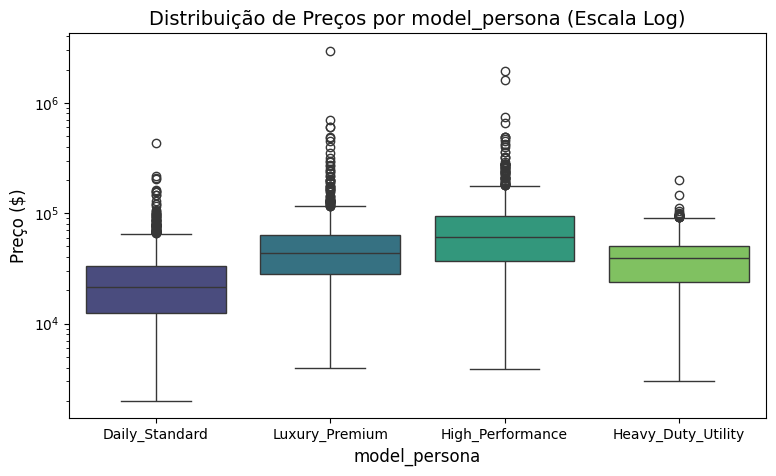

In [2300]:
# Criando boxplot dos preços de veículos, nas classes da variável model_persona

boxplot_price(df_cars, 'model_persona')

O boxplot ratifica a eficácia da segmentação, demonstrando que a variância de preços poder ser explicada pela funcionalidade e status dos modelos:

**High_Performance e Luxury_Premium**: Apresentam as maiores medianas (43k - 60k) e distribuições assimétricas à direita. A presença de outliers extremos (ex: Bugatti e Maserati) confirma o prêmio por exclusividade, mas exige tratamento para não enviesar o modelo.

**Heavy_Duty_Utility**: Exibe um patamar de preço robusto e IQR reduzido, refletindo a alta retenção de valor característica de utilitários e picapes. Esta é a classe de maior homogeneidade.

**Daily_Standard**: Concentra 51% da volumetria com a menor mediana (21.5k). Apresenta menor dispersão em comparação às classes de luxo, refletindo a padronização de preços do mercado de massa.

A distinção entre os intervalos de confiança de cada persona valida o uso desta feature como um preditor para o modelo de regressão.

### Tipo de combustível (*fuel_type*)

In [2301]:
# Distribuição de frequencia da variável fuel_type

analisar_distribuicao(df_cars, 'fuel_type')

--- Análise da Variável: fuel_type ---
Total de classes únicas: 8

                Frequência Absoluta  Frequência Relativa (%)
fuel_type                                                   
Gasoline                       3309                    82.54
Hybrid                          194                     4.84
Electric                        170                     4.24
E85 Flex Fuel                   139                     3.47
Diesel                          116                     2.89
–                                45                     1.12
Plug-In Hybrid                   34                     0.85
not supported                     2                     0.05


In [2302]:
# Imprimindo registros de fuel_type 'not supported'

df_cars[df_cars['fuel_type'] == 'not supported']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,brand_tier,model_persona
2894,Toyota,Mirai Limited,2021,44000.0,not supported,182.0HP Electric Motor Hydrogen Fuel,A/T,Gray,Black,None reported,18500.0,Mainstream,Daily_Standard
3700,Toyota,Mirai Base,2016,40000.0,not supported,151.0HP Electric Motor Hydrogen Fuel,A/T,Silver,Black,None reported,9500.0,Mainstream,Daily_Standard


Podemos perceber que os registros de *fuel_type* 'not supported' se referem, na verdade, a carros elétricos (observe coluna *engine*). Logo, podemos assumir que o *fuel_type* desses registros equivale a categoria 'Electric' criada anteriormente.

In [2303]:
# Imprimindo registros de fuel_type '–'

df_cars[df_cars['fuel_type'] == '–'].head(10)

# Para fins de relatório exibimos apenas 10 registros,
# mas a análise qualitativa foi feita em cima do conjunto completo de registros '-'

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,brand_tier,model_persona
130,Chrysler,Pacifica Touring,2017,87305.0,–,–,9-Speed A/T,Silver,Black,None reported,9000.0,Mainstream,Daily_Standard
257,Toyota,Land Cruiser Base,1993,231500.0,–,–,A/T,White,Gray,None reported,29500.0,Mainstream,Luxury_Premium
338,Mazda,Mazda3 s Grand Touring,2016,85000.0,–,–,A/T,Black,Black,At least 1 accident or damage reported,18500.0,Mainstream,Daily_Standard
491,Chrysler,Pacifica Touring,2017,63000.0,–,–,9-Speed A/T,White,Beige,None reported,20000.0,Mainstream,Daily_Standard
692,Honda,Civic EX,1993,58981.0,–,–,A/T,White,Beige,None reported,9599.0,Mainstream,Daily_Standard
855,Ford,Bronco,1974,6217.0,–,–,–,Dark Gray Metallic,–,None reported,115000.0,Mainstream,Daily_Standard
923,Dodge,Challenger R/T,2010,100100.0,–,–,Transmission w/Dual Shift Mode,Purple,Black,None reported,17000.0,Mainstream,Daily_Standard
995,Dodge,Challenger R/T Scat Pack,2019,43000.0,–,–,6-Speed M/T,Green,Black,None reported,50000.0,Mainstream,High_Performance
1063,Mazda,Mazda6 i Grand Touring,2016,83100.0,–,–,A/T,White,White,None reported,17800.0,Mainstream,Daily_Standard
1083,Dodge,Challenger R/T,2010,73000.0,–,–,A/T,Black,Black,None reported,17500.0,Mainstream,Daily_Standard


Para o tratamento de dados omissos ('-') na variável *fuel_type*, optou-se pela imputação do valor 'Gasoline'. Esta decisão fundamenta-se em duas premissas:

* A análise qualitativa dos registros afetados revelou veículos vintage/antigos e modelos de alta performance (ex: Dodge Challenger), que utilizam predominantemente este combustível.

* Dado que a categoria 'Gasoline' já representa 86% da base, a inclusão desses registros não altera a distribuição da moda e evita a criação de subcategorias com baixa significância estatística.

A potencial distorção de preços causada por veículos de luxo ou colecionáveis dentro desta classe será mitigada pela criação da coluna de Segmentação, que isolará o efeito do valor de mercado desses modelos da variável de combustível.

In [2304]:
# Criação de nova coluna tratada fuel_group, com dados agrupados de fuel_type

# Transforma '-' em Gasoline
df_cars['fuel_type'] = df_cars['fuel_type'].replace('–', 'Gasoline')

# Define os novos grupos
mapeamento_combustivel = {
    'Gasoline': 'Gasoline',
    'Hybrid': 'Green Energy',
    'Plug-In Hybrid': 'Green Energy',
    'Electric': 'Green Energy',
    'not supported': 'Green Energy',
    'Diesel': 'Other Combustion',
    'E85 Flex Fuel': 'Other Combustion'
}

# Aplica agrupamento
df_cars['fuel_group'] = df_cars['fuel_type'].map(mapeamento_combustivel)

# Verifica estatísticas dos novos grupos
comparativo_precos = df_cars.groupby('fuel_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos.to_string())

                          mean   median  count           std     min        max
fuel_group                                                                     
Gasoline          44420.556649  29799.0   3354  85107.627145  2000.0  2954083.0
Green Energy      52042.730000  46500.0    400  29301.740742  4200.0   175000.0
Other Combustion  34549.415686  28999.0    255  24592.215241  4500.0   200000.0


Para otimizar o aprendizado do modelo e reduzir o ruído, a variável *fuel_type* foi reestruturada em três novas classes que refletem as divisões de mercado:

**Gasoline:** Categoria majoritária que engloba veículos convencionais e
modelos de performance/clássicos. Representa o padrão de consumo tradicional.

**Green Energy:** Consolida veículos elétricos e híbridos (incluindo plug-ins). Esta classe agrupa tecnologias de baixa emissão, que possuem curvas de depreciação e incentivos fiscais distintos dos modelos a combustão.

**Other Combustion:** Reúne alternativas como Diesel e Flex Fuel. São nichos específicos, como utilitários pesados ou motores adaptáveis.

Essa consolidação mitiga o problema do desbalanceamento, contribuindo para que o modelo tenha amostras suficientes para identificar padrões.

In [2305]:
# Distribuição de frequencia da variável fuel_group

analisar_distribuicao(df_cars, 'fuel_group')

--- Análise da Variável: fuel_group ---
Total de classes únicas: 3

                  Frequência Absoluta  Frequência Relativa (%)
fuel_group                                                    
Gasoline                         3354                    83.66
Green Energy                      400                     9.98
Other Combustion                  255                     6.36


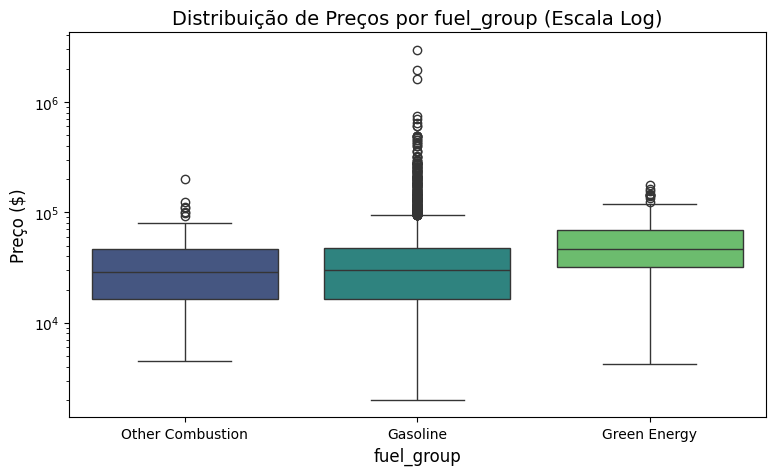

In [2306]:
# Criando boxplot dos preços de veículos, nas classes da variável fuel_group

boxplot_price(df_cars, 'fuel_group')

O boxplot confirma a distinção de mercado entre os grupos: **Green Energy** apresenta a maior mediana de preços, refletindo o custo de novas tecnologias, enquanto **Gasoline** exibe a maior dispersão devido à presença de modelos de luxo e clássicos. O grupo **Other Combustion** mantém um comportamento intermediário e estável. Essa variação de comportamento valida a reestruturação da variável.

### Motor (*engine*)

In [2307]:
# Distribuição de frequencia da variável engine

analisar_distribuicao(df_cars, 'engine')

--- Análise da Variável: engine ---
Total de classes únicas: 1146

                                                                       Frequência Absoluta  Frequência Relativa (%)
engine                                                                                                             
2.0L I4 16V GDI DOHC Turbo                                                              52                     1.30
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel                                            48                     1.20
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel                                            47                     1.17
–                                                                                       45                     1.12
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel                                   44                     1.10
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel                                            42                     1.05
285.0

A coluna original *engine* apresenta uma alta cardinalidade (1.146 variações de texto), o que dificultaria o aprendizado do modelo. Para resolver isso, vamos aplicar uma técnica de Extração de Atributos, transformando uma única coluna de texto em quatro variáveis estruturadas que explicam a variação de preços sob uma perspectiva técnica e comercial:

**Configuração do Motor (*engine_config* - Categórica)**: Consolidamos as diferentes arquiteturas de cilindros (como V6, V8 ou motores em linha). Para o modelo, isso funciona como um indicador de categoria: motores com mais cilindros geralmente equipam veículos de luxo ou alto desempenho, ou seja, indicam um preço mais elevado.

**Potência (*engine_hp* - Numérica)**: Extraímos a cavalaria (Horsepower) como um valor contínuo. Esta é a variável que tende a ter maior correlação com o valor de venda: ela é o principal argumento de mercado para justificar por que um carro custa mais caro que outro dentro da mesma categoria.

**Cilindrada/Litragem do Motor (*engine_displacement* - Numérica)**: Isolamos o tamanho físico do motor (ex: 2.0, 5.7). No contexto de negócio, essa variável ajuda o modelo a entender o porte do veículo: motores maiores são típicos de utilitários e SUVs robustos, que mantêm valores de revenda mais altos devido à sua capacidade de trabalho.

**Presença de Turbo (*is_turbo* - Binária)**: Criamos uma marcação (0 ou 1) para motores com tecnologia Turbo ou Supercharged. Esta variável é um ajuste de precisão: ela explica ao modelo por que um motor pequeno pode ser mais caro que um motor grande.

**Configuração do motor (*engine_config*)**

In [2308]:
# Criando a coluna engine_config

# Cria uma coluna engine_std removendo hifens e espaços
df_cars['engine_std'] = df_cars['engine'].str.lower().str.replace(r'[- ]', '', regex=True)

# Estabelece os padrões que indicam a configuração do motor
# [vwih]\d+ -> Buscas letras v, i, h, w seguidas de números, exemplos: v8, h6, i4, v612
# rotary|electric|ev|dualmotor|120ah -> Busca estes termos em específico
pure_pattern = r'([vihw]\d+|\d+cylinder|electric|ev|dualmotor|120ah|rotary)'

# Extrai informação da configuração para nova coluna
df_cars['engine_config'] = df_cars['engine_std'].str.extract(pure_pattern, expand=False)

# Verifica estatísticas dos novos grupos
extracao_bruta = df_cars.groupby('engine_config', dropna=False)['price'].agg(['mean', 'median', 'count','std'])
print(extracao_bruta.sort_values(by='count', ascending=False))

                       mean     median  count            std
engine_config                                               
8cylinder      4.640131e+04    34500.0   1007   99167.658060
v6             2.939509e+04    25500.0    899   21134.508819
4cylinder      2.247564e+04    19000.0    739   15651.347099
6cylinder      5.437402e+04    43000.0    338   45211.976975
NaN            5.217035e+04    42298.0    208   56079.958116
electric       5.402171e+04    46875.0    168   26928.999923
v624           4.438690e+04    39979.0    165   26510.831848
i416           3.520650e+04    29255.0    157   33073.338102
v816           5.744204e+04    46999.0     72   52896.363139
v832           1.211004e+05    96900.0     64   82916.410713
12cylinder     1.402592e+05    81330.0     37  142755.434199
10cylinder     1.665301e+05   100000.0     23  330753.535864
5cylinder      1.858440e+04    10149.5     20   21073.039629
i312           2.793440e+04    28979.0     15    4090.068630
3cylinder      4.528069e

De todas as variações encontradas originalmente, podemos refinar os dados agrupando termos que possuem o mesmo significado técnico ou posicionamentos de mercado equivalentes. Esta etapa reduz a complexidade do modelo ao consolidar os registros nas seguintes 5 classes:

**Entry_Standard (3 e 4 cilindros)**: Representa o motor de entrada do mercado. É o segmento focado em economia de combustível e alto volume de vendas.

**Mid_Performance (5 e 6 cilindros)**: Identifica veículos com maior potência e, consequentemente, maior valor agregado e prestígio.

**High_V8 (8 cilindros)**: Define o padrão de força (comum em caminhonetes e utilitários) e a performance superior típica de modelos de alto desempenho.

**Exotic (10 e 12 cilindros)**: Ocupa o topo da pirâmide do mercado, onde o preço é regido pela exclusividade e pela engenharia de luxo.

**Electric**: Categoria dedicada exclusivamente à tecnologia de propulsão elétrica, que possui uma lógica de valor e mercado distinta dos modelos a combustão.

**Sem Informação:** Quando não houver informação explícita sobre a configuração do motor.

In [2309]:
# Agrupando configuraçãoes engine_config em classes que fazem sentido de mercado

# Dicionário que define a classe final de cada configuração encontrada
engine_mapping = {
    # Entry_Standard (3 e 4 cilindros)
    '3cylinder': 'Entry_Standard', 'i3': 'Entry_Standard', 'i312': 'Entry_Standard',
    '4cylinder': 'Entry_Standard', 'i4': 'Entry_Standard', 'i416': 'Entry_Standard',
    'i42': 'Entry_Standard', 'h4': 'Entry_Standard', 'h416': 'Entry_Standard',

    # Mid_Performance (5 e 6 cilindros)
    '5cylinder': 'Mid_Performance', 'i5': 'Mid_Performance',
    '6cylinder': 'Mid_Performance', 'v6': 'Mid_Performance', 'v612': 'Mid_Performance',
    'v618': 'Mid_Performance', 'v624': 'Mid_Performance', 'i6': 'Mid_Performance',
    'i624': 'Mid_Performance', 'h6': 'Mid_Performance', 'h624': 'Mid_Performance',

    # High_V8 (8 cilindros)
    '8cylinder': 'High_V8', 'v8': 'High_V8', 'v816': 'High_V8',
    'v832': 'High_V8', 'v86': 'High_V8',

    # Exotic
    '10cylinder': 'Exotic', 'v10': 'Exotic', 'v1040': 'Exotic',
    '12cylinder': 'Exotic', 'v12': 'Exotic', 'v1248': 'Exotic',
    'w12': 'Exotic', 'w1248': 'Exotic', 'w1664': 'Exotic',
    'rotary': 'Exotic',

    # Electric
    'electric': 'Electric', 'ev': 'Electric', 'dualmotor': 'Electric', '120ah': 'Electric'
}
# Aplica dicionário na coluna orginal engine_config
df_cars['engine_config'] = df_cars['engine_config'].map(engine_mapping)

# Preenche os registros nulos com 'Sem Informação'
df_cars['engine_config'] = df_cars['engine_config'].fillna('Sem Informação')

# Verifica estatísticas dos novos grupos
resumo = df_cars.groupby('engine_config')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(resumo.to_string())

                          mean    median  count            std     min        max
engine_config                                                                    
Electric          53602.531792   46598.0    173   26690.556783  4200.0   146000.0
Entry_Standard    25121.591489   22000.0    940   20435.754511  2300.0   299000.0
Exotic           216784.179775  129000.0     89  293206.285296  6800.0  1950995.0
High_V8           51805.856522   37900.0   1150   97753.639450  2000.0  2954083.0
Mid_Performance   38650.273292   30500.0   1449   37054.891506  2300.0   489000.0
Sem Informação    52170.350962   42298.0    208   56079.958116  2500.0   599995.0


In [2310]:
# Distribuição de frequencia da variável engine_config

analisar_distribuicao(df_cars, 'engine_config')

--- Análise da Variável: engine_config ---
Total de classes únicas: 6

                 Frequência Absoluta  Frequência Relativa (%)
engine_config                                                
Mid_Performance                 1449                    36.14
High_V8                         1150                    28.69
Entry_Standard                   940                    23.45
Sem Informação                   208                     5.19
Electric                         173                     4.32
Exotic                            89                     2.22


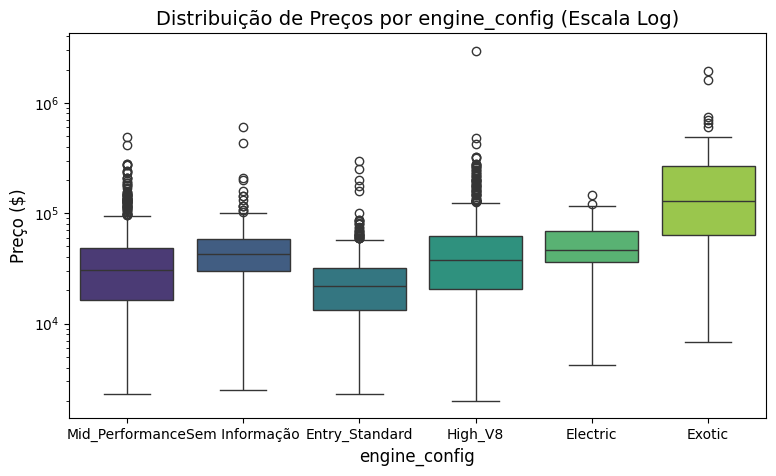

In [2311]:
# Criando boxplot dos preços de veículos, nas classes da variável engine_config

boxplot_price(df_cars, 'engine_config')

O boxplot reflete uma hierarquia de preços entre as novas categorias de motorização, validando a estratégia:

A classe **Entry_Standard** apresenta a menor mediana (21.995 USD), confirmando seu papel como base do mercado. Já a **Mid_Performance** mostra um degrau claro de valor (mediana de 30.000 USD), consolidando veículos com maior valor agregado.

As classes **High_V8** e **Electric** apresentam comportamentos de preço superiores, com medianas na faixa de 37k USD a 46k USD, indicando uma base de preços mais alta devido à tecnologia.

Como esperado, a classe **Exotic** é um outlier por natureza. Com a maior mediana do dataset (115.000 USD) e uma média ainda mais alta, ela isola os veículos de luxo extremo e alta cilindrada, contribuindo para que esse perfil não afete o aprendizado do modelo nos segmentos de volume.

Esta separação visual no boxplot é um excelente sinal para o modelo de Machine Learning, pois indica que a variável *engine_config* agora possui poder discriminatório sobre o preço.

**Potência (*engine_hp*)**

In [2312]:
# Criando a coluna engine_hp numérica

# Coloca todas as strings em letra minúscula
df_cars['engine_std'] = df_cars['engine'].str.lower()

# Estabelece os padrões que indicam o horsepower
# Busca números com ou sem casas decimais seguidos por hp
#regex_pattern = r'(\d+\.?\d*)hp'
regex_pattern = r'(\d+\.?\d*)\s?hp'

# Extrai informação do hp para nova coluna
df_cars['engine_hp'] = df_cars['engine_std'].str.extract(regex_pattern, expand=False).astype(float)

print(f"Sucesso: {df_cars['engine_hp'].notnull().sum()} linhas")

Sucesso: 3201 linhas


Tratamento de dados ausentes em ***engine_hp***:
A extração via RegEx obteve sucesso em 80% da base (3.201 registros). Para os 20% remanescentes (808 registros), aplicaremos a estratégia de imputação por mediana agrupada:

O preenchimento será realizado com base na mediana de hp de cada categoria da coluna ***engine_config***. O uso da mediana, em vez da média, evita distorções causadas por outliers.

Para registros sem configuração de motor identificada, utilizaremos a mediana global da base como salvaguarda.

In [2313]:
# Tratamento de missing em engine_hp

# Substituiu NAs em engine_hp, pela mediana de engine_hp em cada grupo de engine_config
df_cars['engine_hp'] = df_cars['engine_hp'].fillna(df_cars.groupby('engine_config')['engine_hp'].transform('median'))

# Preenche o que restou com a mediana de toda a coluna
mediana_global = df_cars['engine_hp'].median()
df_cars['engine_hp'] = df_cars['engine_hp'].fillna(mediana_global)

print(f"Nulos finais: {df_cars['engine_hp'].isnull().sum()}")

Nulos finais: 0


In [2314]:
# Estatísticas descritivas da variável engine_hp, em cada classe de engine_config

df_cars.groupby('engine_config')['engine_hp'].agg(['mean', 'median', 'count', 'std', 'min', 'max'])

,mean,median,count,std,min,max
engine_config,,,,,,
Electric,453.462428,425.0,173,188.358068,107.0,1020.0
Entry_Standard,210.658511,206.0,940,50.765465,70.0,455.0
Exotic,537.022472,552.0,89,101.607755,212.0,788.0
High_V8,412.305217,402.0,1150,89.783125,180.0,808.0
Mid_Performance,313.437543,304.0,1449,67.280770,140.0,640.0
Sem Informação,305.000000,305.0,208,0.000000,305.0,305.0


In [2315]:
# Definindo função que cria gráfico boxplot de determinada variável numérica, para as classes de configuração do motor

def boxplot_engine_config (variavel_numerica):
    # Cria espaço para o gráfico
    plt.figure(figsize=(9, 5))

    # Cria o gráfico Boxplot
    sns.boxplot(x='engine_config', y=variavel_numerica, data=df_cars,
                palette='viridis',
                order = ['Entry_Standard','Mid_Performance','High_V8','Exotic','Electric','Sem Informação'],
                hue='engine_config',
                legend=False)

    # Ajusta a escala
    plt.yscale('log') # Escala logarítmica para lidar com outliers extremos

    # Inclui os títulos
    plt.title(f'Distribuição de {variavel_numerica} por Configuração de motor (Escala Log)', fontsize=14)
    plt.xlabel('engine_config', fontsize=12)
    plt.ylabel(f'{variavel_numerica}', fontsize=12)


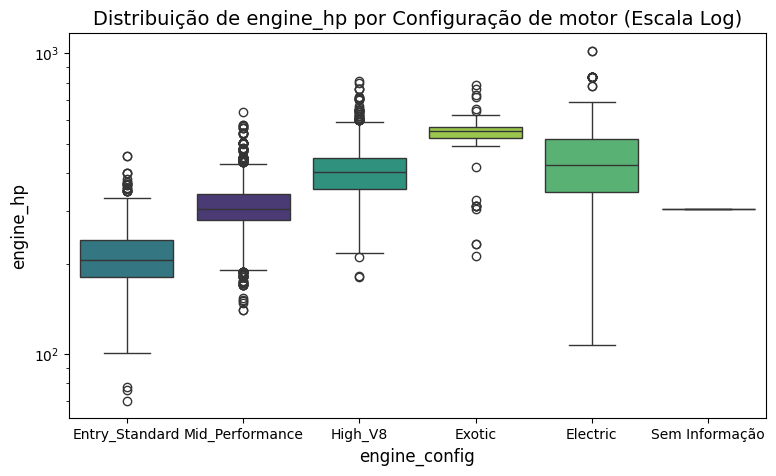

In [2316]:
# Desenhando o boxplot de engine_hp, nas classes de engine_config

boxplot_engine_config('engine_hp')

O Boxplot revela o comportamento de potência dentro de cada configuração de motor, permitindo as seguintes observações principais:

* Existe uma progressão clara e esperada das medianas. O grupo **Entry_Standard** apresenta o menor patamar de potência, seguido por **Mid_Performance**, **High_V8** e **Exotic**, validando a consistência da classificação de motores e respectiva potência.

* O grupo **Electric** destaca-se por possuir o maior Intervalo Interquartil (IQR) e o maior desvio padrão (188.3). Isso indica uma alta dispersão, uma vez que a categoria abriga desde veículos urbanos de baixa potência até superesportivos de alta performance.

* A proximidade entre média e mediana na maioria dos grupos indica distribuições relativamente simétricas, com poucos valores extremos fugindo do comportamento padrão de cada arquitetura de motor.

* Os valores mínimos e máximos de potência (hp) por categoria mostram-se tecnicamente condizentes com a realidade do mercado automobilístico, não demandando tratamentos específicos para outliers além das imputações já realizadas.

**Cilindrada/Litragem do Motor (*engine_displacement*)**



In [2317]:
# Criando a coluna engine_displacement numérica

# A coluna df_cars['engine_std'] será usada novamente (letras minúsculas)
#df_cars['engine_std'] = df_cars['engine'].str.lower()

# Estabelece os padrões que indicam a litragem
# Busca números com ou sem casas decimais seguidos ou não por espaço e depois l ou liter
regex_displacement = r'(\d+\.?\d*)\s?(?:l|liter)'

# Extrai informação dos litros para nova coluna
df_cars['engine_displacement'] = df_cars['engine_std'].str.extract(regex_displacement, expand=False).astype(float)

print(f"Sucesso: {df_cars['engine_displacement'].notnull().sum()} linhas")

Sucesso: 3792 linhas


Tratamento de dados ausentes em ***engine_displacement***:
A extração via RegEx obteve sucesso em 95% da base (3.792 registros). Para os 5% remanescentes (217 registros), aplicaremos a estratégia de imputação por mediana agrupada:

O preenchimento será realizado com base na mediana de litragem de cada categoria da coluna ***engine_config***. O uso da mediana, em vez da média, evita distorções causadas por outliers.

Exceção da categoria ***Electric***: Nesta categoria, a informação de litragem não se aplica ao motor elétrico, ocorrendo apenas em casos particulares de híbridos ou extensores de autonomia. Por questões de consistência e conhecimento de domínio, adotamos a estratégia de preencher toda esta categoria com *engine_displacement = 0.0*.

In [2318]:
# Tratamento de missing em engine_displacement

# Força engine_displacement = 0.0 para carros elétricos
df_cars.loc[df_cars['engine_config'] == 'Electric', 'engine_displacement'] = 0.0

# Substituiu NAs em engine_displacement, pela mediana de engine_displacement em cada grupo de engine_config
df_cars['engine_displacement'] = df_cars['engine_displacement'].fillna(df_cars.groupby('engine_config')['engine_displacement'].transform('median'))

print(f"Nulos finais: {df_cars['engine_displacement'].isnull().sum()}")

Nulos finais: 0


In [2319]:
# Estatísticas descritivas da variável engine_displacement, em cada classe de engine_config

df_cars.groupby('engine_config')['engine_displacement'].agg(['mean', 'median', 'count', 'std', 'min', 'max'])

,mean,median,count,std,min,max
engine_config,,,,,,
Electric,0.000000,0.0,173,0.000000,0.0,0.0
Entry_Standard,2.065638,2.0,940,0.309316,1.0,3.8
Exotic,5.886517,6.0,89,1.166599,1.3,8.4
High_V8,5.280435,5.3,1150,0.820243,3.8,8.1
Mid_Performance,3.410904,3.5,1449,0.531915,2.5,6.7
Sem Informação,3.086538,3.0,208,0.979358,1.5,6.6


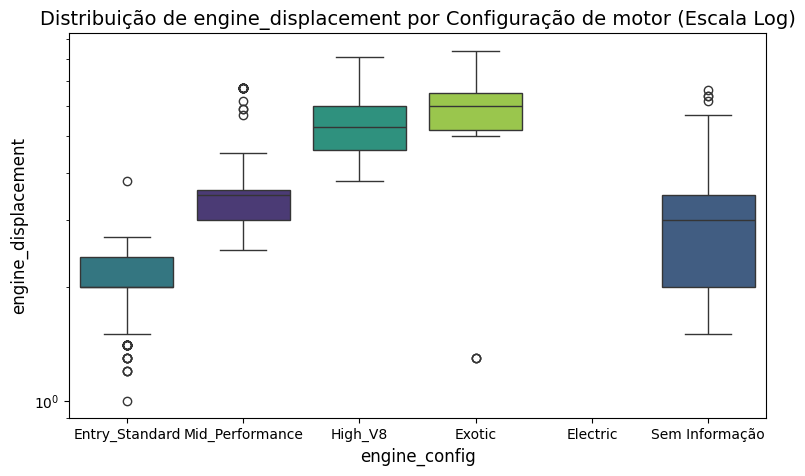

In [2320]:
# Desenhando o boxplot de engine_displacement, nas classes de engine_config

boxplot_engine_config('engine_displacement')

O Boxplot revela o comportamento da cilindrada dentro de cada configuração de motor, permitindo as seguintes observações:

* Observa-se uma progressão clara e coerente das medianas entre os motores a combustão. O grupo **Entry_Standard** apresenta o menor volume médio (2.0L), seguido por **Mid_Performance** (3.5L), **High_V8** (5.3L) e **Exotic** (6.0L), confirmando a precisão da categorização mecânica.

* O grupo **Exotic** apresenta a maior dispersão (maior desvio padrão, 1.16), refletindo a coexistência de tecnologias distintas, desde motores rotativos compactos até propulsores de alta litragem.

* A categoria **Electric** apresenta variância e mediana zero, resultado da estratégia de imputação por domínio, que isola corretamente os veículos sem motor de combustão interna.

* A forte convergência entre média e mediana em todos os grupos indica distribuições bem comportadas e simétricas dentro de cada classe.

* Os valores mínimos e máximos de cilindrada por categoria mostram-se tecnicamente condizentes com a realidade do mercado automobilístico, não demandando tratamentos específicos para outliers.

**Presença de turbo (*is_turbo*)**

In [2321]:
# Criando uma coluna booleana para identificar turbo
df_cars['is_turbo'] = df_cars['engine_std'].str.contains(r'turbo|supercharge', na=False)

# Verificação da distribuição por categoria de motor
print(df_cars.groupby('engine_config')['is_turbo'].value_counts(normalize=True) * 100)

engine_config    is_turbo
Electric         False       100.000000
Entry_Standard   False        87.872340
                 True         12.127660
Exotic           False        89.887640
                 True         10.112360
High_V8          False        95.652174
                 True          4.347826
Mid_Performance  False        95.100069
                 True          4.899931
Sem Informação   False        69.230769
                 True         30.769231
Name: proportion, dtype: float64


A extração da presença de Turbo/Supercharger por categoria de motor validou a consistência dos dados para o modelo de precificação:

* A categoria **Electric** apresenta 100% de registros como False, confirmando a ausência de indução forçada em motores elétricos.

* No grupo **Entry_Standard**, a incidência de 12,1% reflete a tendência de downsizing, onde motores de baixa litragem utilizam turbocompressores para ganho de eficiência e performance.

* Nas categorias **High_V8** e **Exotic**, a predominância de motores aspirados (acima de 89%) é coerente com modelos esportivos de alta cilindrada.

* O grupo Sem Informação apresenta a maior taxa de identificação positiva (30,8%). Isso demonstra que a variável booleana irá permitir que o modelo diferencie a performance de veículos cujos detalhes de cilindros não foram explicitamente declarados.

### Transmissão (*transmission*)

In [2322]:
# Distribuição de frequencia da variável transmission

analisar_distribuicao(df_cars, 'transmission')

--- Análise da Variável: transmission ---
Total de classes únicas: 62

                                                                  Frequência Absoluta  Frequência Relativa (%)
transmission                                                                                                  
A/T                                                                              1037                    25.87
8-Speed A/T                                                                       406                    10.13
Transmission w/Dual Shift Mode                                                    398                     9.93
6-Speed A/T                                                                       362                     9.03
6-Speed M/T                                                                       248                     6.19
Automatic                                                                         237                     5.91
7-Speed A/T                              

O código a seguir realiza a redução de granularidade da variável *transmission*, consolidando diversas nomenclaturas técnicas em categorias funcionais para o modelo de regressão.

A função utiliza mapeamento de padrões de texto para agrupar variações como CVT, DCT, PDK e Variable sob o rótulo **Automatic**, enquanto siglas como M/T são classificadas como **Manual**.

O uso da categoria **Other** serve como um filtro de auditoria para identificar inconsistências de preenchimento ou transmissões exóticas, garantindo que o modelo não seja treinado com ruído.

In [2323]:
# Definindo novas classes de transmissão, baseadas nas caracteristicas manual x automática

def transmission_cleanup(transmission_string):
    clean_text = str(transmission_string).upper().strip()

    # Identifica tecnologias de câmbio manual
    if any(x in clean_text for x in ['MANUAL', 'M/T', 'MT']):
        return 'Manual'

    # Identifica tecnologias de câmbio automático
    auto_patterns = [
        'A/T', 'AT', 'AUTOMATIC', 'AUTO', 'CVT', 'DCT', 'VARIABLE','DSG', 'PDK',
        'SHIFT', 'SINGLE', 'FIXED', '1-SPEED', 'OVERDRIVE']
    if any(pattern in clean_text for pattern in auto_patterns):
        return 'Automatic'

    # Fallback
    return 'Other'

# Aplica transformação ao dataset original
df_cars['transmission_grouped'] = df_cars['transmission'].apply(transmission_cleanup)

# Verifica estatísticas dos novos grupos criados
print(df_cars.groupby('transmission_grouped')['price'].agg(['mean', 'median', 'count','std','min','max']))

                               mean   median  count            std      min  \
transmission_grouped                                                          
Automatic              44478.282242  32000.0   3621   75329.425141   2000.0   
Manual                 41447.513298  24000.0    376   96132.022944   2300.0   
Other                 164467.916667  54498.0     12  242624.888366  14798.0   

                            max  
transmission_grouped             
Automatic             2954083.0  
Manual                1599000.0  
Other                  749950.0  


In [2324]:
# Analisando os registros que caíram no grupo 'Other'

df_cars[df_cars['transmission_grouped'] == 'Other']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,brand_tier,model_persona,fuel_group,engine_std,engine_config,engine_hp,engine_displacement,is_turbo,transmission_grouped
5,Acura,ILX 2.4L,2016,136397.0,Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,14798.0,Premium,Daily_Standard,Gasoline,2.4 liter,Sem Informação,305.0,2.4,False,Other
269,Acura,TLX w/A-Spec Package,2022,14896.0,Gasoline,2.0 Liter DOHC Turbo,2,Lunar Silver Metallic,Ebony,None reported,39998.0,Premium,Daily_Standard,Gasoline,2.0 liter dohc turbo,Sem Informação,305.0,2.0,True,Other
476,Acura,MDX w/Technology Package,2023,3415.0,Gasoline,3.5 Liter SOHC,F,White,Parchment.,None reported,54998.0,Premium,Luxury_Premium,Gasoline,3.5 liter sohc,Sem Informação,305.0,3.5,False,Other
516,Acura,MDX w/Technology Package,2022,30177.0,Gasoline,3.5L 24V SOHC I-VTEC V6,2,Majestic Black Pearl,Espresso,None reported,46598.0,Premium,Luxury_Premium,Gasoline,3.5l 24v sohc i-vtec v6,Mid_Performance,304.0,3.5,False,Other
536,Porsche,911 Carrera S,2017,16701.0,Gasoline,3.0 Liter,–,Red,–,None reported,107998.0,Luxury_Exotic,High_Performance,Gasoline,3.0 liter,Sem Informação,305.0,3.0,False,Other
855,Ford,Bronco,1974,6217.0,Gasoline,–,–,Dark Gray Metallic,–,None reported,115000.0,Mainstream,Daily_Standard,Gasoline,–,Sem Informação,305.0,3.0,False,Other
916,Porsche,911 Carrera 4S,2018,31678.0,Gasoline,3.0 Liter,–,Silver,–,None reported,106798.0,Luxury_Exotic,High_Performance,Gasoline,3.0 liter,Sem Informação,305.0,3.0,False,Other
1236,Toyota,Tacoma TRD Pro,2019,40698.0,Gasoline,3.5L V6 24V PDI DOHC,6-Speed,Super White,Black,None reported,42886.0,Mainstream,Heavy_Duty_Utility,Gasoline,3.5l v6 24v pdi dohc,Mid_Performance,304.0,3.5,False,Other
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,Gasoline,6.5L V12 48V MPFI DOHC,7-Speed,–,Nero Ade,None reported,749950.0,Luxury_Exotic,High_Performance,Gasoline,6.5l v12 48v mpfi dohc,Exotic,552.0,6.5,False,Other
1615,Rolls-Royce,Phantom,2023,1560.0,Gasoline,–,–,Tempest,Cobalt Blue,None reported,599995.0,Luxury_Exotic,Luxury_Premium,Gasoline,–,Sem Informação,305.0,3.0,False,Other


Após uma **análise qualitativa** dos 12 registros residuais, identificamos que a categoria **Other** era composta majoritariamente por inconsistências de preenchimento em modelos convencionais (ex: Acura) e veículos de altíssimo luxo (Lamborghini, Rolls-Royce) com nomenclaturas proprietárias.
Optaremos pela consolidação desses casos na classe Automatic, uma vez que todos operam mecanicamente sem pedal de embreagem. Esta decisão elimina o viés de uma categoria pouco representativa.

In [2325]:
# Incluindo a classe Other dentro de Automatic

df_cars['transmission_grouped'] = df_cars['transmission_grouped'].replace('Other', 'Automatic')

In [2326]:
# Distribuição de frequencia da variável transmission_grouped

analisar_distribuicao(df_cars, 'transmission_grouped')

--- Análise da Variável: transmission_grouped ---
Total de classes únicas: 2

                      Frequência Absoluta  Frequência Relativa (%)
transmission_grouped                                              
Automatic                            3633                    90.62
Manual                                376                     9.38


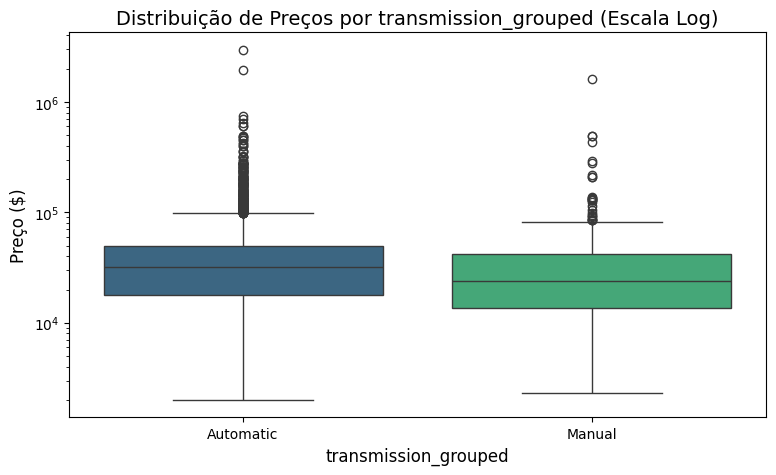

In [2327]:
# Criando boxplot dos preços de veículos, nas classes da variável transmission_grouped

boxplot_price(df_cars, 'transmission_grouped')

O boxplot ratifica a segmentação de mercado: a categoria **Manual** apresenta a menor mediana de preços, refletindo a desvalorização dessa tecnologia em veículos convencionais no mercado americano, onde o câmbio automático se tornou o padrão de consumo.

### Cor externa (*ext_col*)

In [2328]:
# Distribuição de frequencia da variável ext_col

analisar_distribuicao(df_cars, 'ext_col')

--- Análise da Variável: ext_col ---
Total de classes únicas: 319

                                    Frequência Absoluta  Frequência Relativa (%)
ext_col                                                                         
Black                                               905                    22.57
White                                               816                    20.35
Gray                                                496                    12.37
Silver                                              374                     9.33
Blue                                                349                     8.71
Red                                                 261                     6.51
Green                                                74                     1.85
Brown                                                43                     1.07
Gold                                                 42                     1.05
Beige                                     

Para a variável de cor externa (*ext_col*), identificou-se inicialmente uma alta cardinalidade, com centenas de variações nominais. O primeiro passo para o tratamento desses dados consiste em uma limpeza para a extração da nomenclatura genérica das cores, reduzindo a complexidade da coluna e padronizando as categorias para a análise.



In [2329]:
# Define função que agrupa nomenclaturas diferentes para a mesma cor e joga ocorrências menos comuns em Outros

def simplify_color(color):
    c = str(color).lower()

    if 'white' in c or 'blanc' in c or 'bianco' in c or 'pearl' in c: return 'White'
    if 'black' in c or 'jet' in c or 'ebony' in c or 'obsidian' in c or 'nero' in c or 'onyx' in c: return 'Black'
    if 'gray' in c or 'grey' in c or 'granite' in c or 'charcoal' in c or 'slate' in c or 'ash' in c: return 'Gray'
    if 'silver' in c or 'billet' in c or 'iconic' in c: return 'Silver'
    if 'blue' in c or 'navy' in c or 'blu' in c or 'indigo' in c or 'azure' in c: return 'Blue'
    if 'red' in c or 'rosso' in c or 'crimson' in c or 'scarlet' in c or 'pimento' in c: return 'Red'
    if 'beige' in c or 'tan' in c or 'sand' in c or 'parchment' in c or 'almond' in c or 'ivory' in c: return 'Beige'
    if 'brown' in c or 'mocha' in c or 'saddle' in c or 'espresso' in c or 'cocoa' in c or 'bronze' in c: return 'Brown'
    if 'green' in c or 'verde' in c or 'emerald' in c or 'olive' in c: return 'Green'
    if 'gold' in c: return 'Gold'
    if 'orange' in c or 'arancio' in c or 'mango' in c: return 'Orange'
    if 'yellow' in c or 'giallo' in c: return 'Yellow'

    return 'Other'

In [2330]:
# Simplificando a coluna ext_col

df_cars['ext_col_simple'] = df_cars['ext_col'].apply(simplify_color)

print(df_cars['ext_col_simple'].value_counts(normalize=True)*100)

ext_col_simple
Black     25.342978
White     24.045897
Gray      13.744076
Silver    10.526316
Blue       9.802943
Red        7.657770
Green      2.020454
Other      1.845847
Brown      1.147418
Beige      1.097531
Gold       1.047643
Orange     0.972811
Yellow     0.748316
Name: proportion, dtype: float64


 O segundo passo será consolidar essas 13 cores em 5 categorias principais, baseadas em critérios de liquidez:

 * **Neutral_Dark**: composto por Black e Gray, cores de alta demanda e perfil corporativo.
 * **Neutral_Light**: reúne White e Silver, o padrão de mercado de fácil revenda.
 * **Chroma_Standard**: inclui Blue e Red, cores vibrantes de massa, comuns em modelos de entrada.
 * **Earth_Tones**: agrupa Brown, Beige e Gold, tons sóbrios associados a veículos de luxo.
 * **Vibrant_Rare**: engloba Green, Orange, Yellow e a categoria Other, que são cores de nicho com baixa representatividade individual.

Esta simplificação reduz a dimensionalidade do dataset (após encoding), o que resulta em um modelo de execução mais rápida e com melhor capacidade de generalização para novos dados.

In [2331]:
# Define função que agrupa cores em classes de ext_col
def group_ext(color):
    if color in ['Black', 'Gray']: return 'Neutral_Dark'
    if color in ['White', 'Silver']: return 'Neutral_Light'
    if color in ['Blue', 'Red']: return 'Chroma_Standard'
    if color in ['Brown', 'Beige', 'Gold']: return 'Earth_Tones'
    return 'Vibrant_Rare'

# Aplica a função aos valores de ext_col
df_cars['ext_col_group'] = df_cars['ext_col_simple'].apply(group_ext)

# Imprime classes de ext_col e sua frequência
print(df_cars['ext_col_group'].value_counts(normalize=True)*100)

ext_col_group
Neutral_Dark       39.087054
Neutral_Light      34.572213
Chroma_Standard    17.460713
Vibrant_Rare        5.587428
Earth_Tones         3.292592
Name: proportion, dtype: float64


In [2332]:
# Calculando estatísticas de preço nos grupos de cores

comparativo_precos = df_cars.groupby('ext_col_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)

                         mean   median  count            std     min  \
ext_col_group                                                          
Chroma_Standard  46418.025714  30000.0    700  122038.684007  2300.0   
Earth_Tones      28277.727273  17250.0    132   34316.881282  3200.0   
Neutral_Dark     44130.518188  33000.0   1567   58374.420312  2000.0   
Neutral_Light    41657.803752  29970.0   1386   69247.527183  2500.0   
Vibrant_Rare     69188.500000  41999.5    224   97118.795276  2300.0   

                       max  
ext_col_group               
Chroma_Standard  2954083.0  
Earth_Tones       217000.0  
Neutral_Dark     1599000.0  
Neutral_Light    1950995.0  
Vibrant_Rare      749950.0  


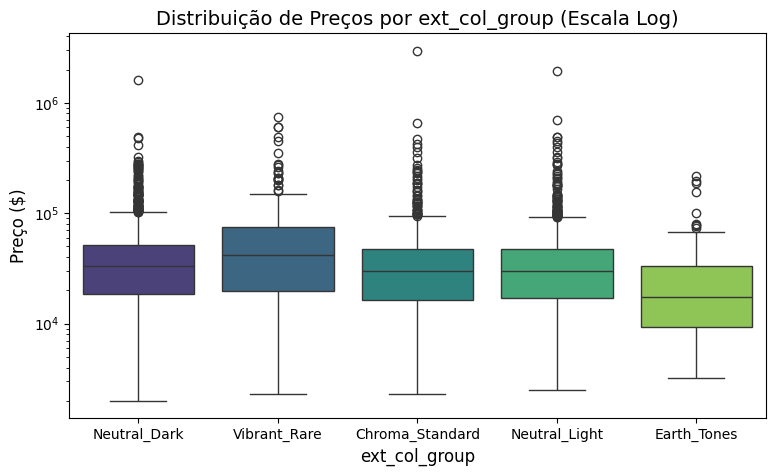

In [2333]:
# Criando boxplot dos preços de veículos, nas classes da variável ext_col

boxplot_price(df_cars, 'ext_col_group')

A análise dos grupos de cores externas revela padrões distintos de valorização e a presença marcante de valores atípicos (outliers):

* A categoria **Vibrant_Rare** apresenta a maior mediana (41.999 USD), indicando que cores exóticas estão frequentemente associadas a veículos de nicho ou de maior valor agregado nesta base.

* Observa-se uma forte assimetria em todas as categorias, com médias sistematicamente superiores às medianas, sugerindo que modelos de luxo estão distorcendo a média para cima.

* A categoria **Earth_Tones** apresenta o menor ticket médio e mediana, concentrando-se em uma faixa de preço mais acessível e com menor dispersão de valores extremos em comparação aos demais grupos.

Em suma, o boxplot demonstra que a cor não será o fator determinante para a diferenciação de preço no modelo, visto que as medianas das categorias são próximas e a volatilidade interna de cada grupo é extremamente alta.

### Cor interna (*int_col)*

In [2334]:
# Distribuição de frequencia da variável int_col

analisar_distribuicao(df_cars, 'int_col')

--- Análise da Variável: int_col ---
Total de classes únicas: 156

                       Frequência Absoluta  Frequência Relativa (%)
int_col                                                            
Black                                 2025                    50.51
Beige                                  538                    13.42
Gray                                   472                    11.77
Brown                                  157                     3.92
–                                      133                     3.32
White                                  127                     3.17
Red                                    126                     3.14
Jet Black                               59                     1.47
Ebony                                   44                     1.10
Blue                                    29                     0.72
Orange                                  20                     0.50
Silver                                  16       

Similarmente ao que foi feito para as cores externas, o primeiro passo para o tratamento da coluna *int_col* consiste na extração da nomenclatura genérica das cores, reduzindo a complexidade e padronizando as categorias para a análise.

In [2335]:
# Simplificando a coluna int_col

df_cars['int_col_simple'] = df_cars['int_col'].apply(simplify_color)

print(df_cars['int_col_simple'].value_counts(normalize=True)*100)

int_col_simple
Black     55.400349
Beige     14.093290
Gray      12.596658
Other      4.764280
Brown      4.165627
White      3.342479
Red        3.317536
Blue       0.848092
Orange     0.573709
Silver     0.399102
Gold       0.249439
Green      0.199551
Yellow     0.049888
Name: proportion, dtype: float64


Para a variável de cor interna, a limpeza revelou que a cor Black domina mais de 55% da base. Aplicaremos também uma simplificação de 5 categorias para refletir o padrão de acabamento e a percepção de valor dos veículos.

* **Standard_Dark**: é composto apenas por Black, representando a maior fatia do mercado.
* **Standard_Light**: reúne Beige e Gray, cores tradicionais que somam mais de 26% dos dados e oferecem sensação de amplitude.
* **Premium_Earth**: consolida Brown e White, tons que frequentemente sinalizam sofisticação e acabamentos diferenciados.
* **Chroma_Sport**: inclui Red e Blue, cores geralmente associadas a pacotes de design esportivo.
* **Exotic_Rare**: engloba Orange, Silver, Gold, Green, Yellow e a categoria Other, unindo opções de nicho com baixa frequência.

Este tratamento garante que o modelo não sofra com a dispersão dos dados e consiga capturar o impacto real do acabamento interno no preço final.

In [2336]:
# Define função que agrupa cores em classes de int_col
def group_int(color):
    if color == 'Black': return 'Standard_Dark'
    if color in ['Beige', 'Gray']: return 'Standard_Light'
    if color in ['Brown', 'White']: return 'Premium_Earth'
    if color in ['Red', 'Blue']: return 'Chroma_Sport'
    return 'Exotic_Rare'

# Aplica a função aos valores de int_col
df_cars['int_col_group'] = df_cars['int_col_simple'].apply(group_int)

# Imprime classes de int_col e sua frequência
print(df_cars['int_col_group'].value_counts(normalize=True)*100)

int_col_group
Standard_Dark     55.400349
Standard_Light    26.689948
Premium_Earth      7.508107
Exotic_Rare        6.235969
Chroma_Sport       4.165627
Name: proportion, dtype: float64


In [2337]:
# Calculando estatísticas de preço nos grupos de cores

comparativo_precos = df_cars.groupby('int_col_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)

                        mean   median  count            std     min        max
int_col_group                                                                 
Chroma_Sport    63260.107784  42000.0    167   81128.766893  4900.0   695000.0
Exotic_Rare     61731.792000  38798.0    250   81468.822597  2500.0   599000.0
Premium_Earth   57790.099668  39998.0    301  119512.832230  4500.0  1950995.0
Standard_Dark   45866.369653  34000.0   2221   59478.450975  2500.0  1599000.0
Standard_Light  31170.399065  20000.0   1070   94600.192805  2000.0  2954083.0


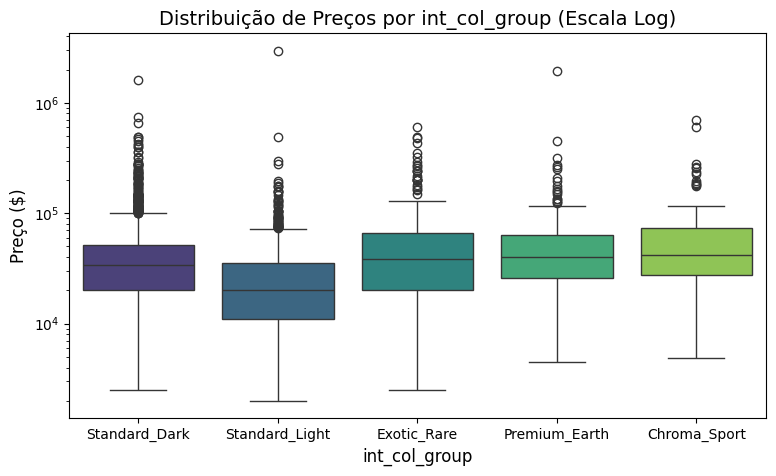

In [2338]:
# Criando boxplot dos preços de veículos, nas classes da variável int_col

boxplot_price(df_cars, 'int_col_group')

A partir do boxplot acima podemos observar:

* As categorias **Chroma_Sport, Exotic_Rare e Premium_Earth** apresentam as maiores medianas (entre 38k USD e 42k USD), sugerindo que interiores coloridos, exóticos ou em tons de luxo (como marrom e branco) estão frequentemente atrelados a veículos de maior valor agregado.

* Observa-se uma forte assimetria em todas as classes, com médias sistematicamente superiores às medianas, indicando que modelos de luxo estão puxando as médias para cima.

* A categoria **Standard_Dark** confirma sua posição como o padrão de volume do mercado, tendo um desvio padrão inferior aos demais grupos de nicho.

Em suma, o boxplot demonstra que a cor interna não será o fator determinante para a diferenciação de preço no modelo, visto que as medianas das categorias são próximas e a volatilidade interna de cada grupo é extremamente alta, indicando que o acabamento é um preditor complementar frente a variáveis mais pesadas como marca e ano.

### Ano do modelo (*model_year*)

In [2339]:
# Distribuição de frequencia da variável model_year

analisar_distribuicao(df_cars, 'model_year')

--- Análise da Variável: model_year ---
Total de classes únicas: 34

            Frequência Absoluta  Frequência Relativa (%)
model_year                                              
2022                        354                     8.83
2021                        350                     8.73
2020                        322                     8.03
2018                        315                     7.86
2019                        297                     7.41
2016                        268                     6.68
2017                        259                     6.46
2015                        228                     5.69
2023                        226                     5.64
2014                        181                     4.51
2013                        158                     3.94
2012                        141                     3.52
2011                        124                     3.09
2008                        113                     2.82
2010               

A transformação da variável *model_year* em *vehicle_age* (idade do veículo) foi escolhida pelos seguintes motivos:

* A idade reduz a escala numérica. Números menores e começando em zero são matematicamente mais eficientes para a convergência de algoritmos e tornam a análise mais intuitiva.
* Se o modelo for usado no futuro terá dificuldade de extrapolar o ano. Já o conceito de idade, permanece válido independentemente do ano civil.
* A desvalorização automotiva é uma função do tempo de uso e não do rótulo do calendário. A idade correlaciona-se diretamente com o desgaste físico e a obsolescência tecnológica.

Regra Aplicada: *vehicle_age* = 2024 - *model_year* (2024 é o ano máximo da base de dados).

In [2340]:
# Criando uma nova coluna de idade, usando 2024 como referência

df_cars['vehicle_age'] = 2024 - df_cars['model_year']

In [2341]:
df_cars['vehicle_age'].describe()


,vehicle_age
count,4009.000000
mean,8.484410
std,6.104816
min,0.000000
25%,4.000000
50%,7.000000
75%,12.000000
max,50.000000


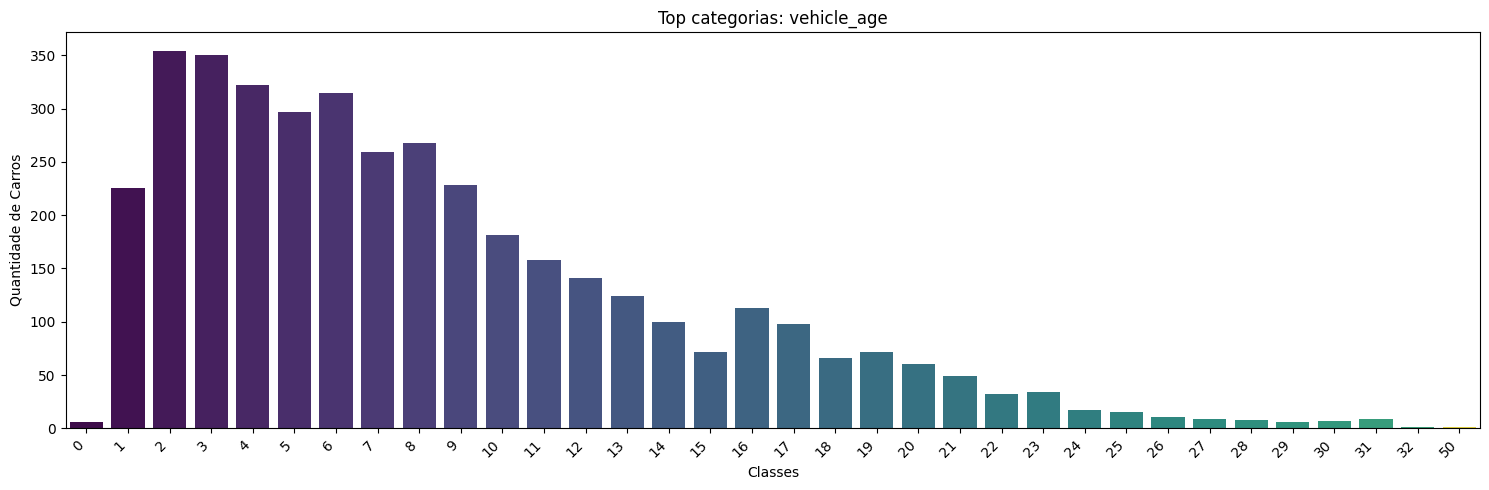

In [2342]:
# Gráfico de barras das categorias da variável vehicle_age

grafico_distribuicao(df_cars, 'vehicle_age')

A transformação da variável *model_year* em *vehicle_age* (idade do veículo) preservou a estrutura da distribuição, mas inverteu sua polaridade: a moda agora se concentra em 2 anos.
A assimetria, que anteriormente era negativa (concentrada em anos recentes), tornou-se positiva, apresentando uma cauda longa que representa os veículos de idade avançada.

## 5.3 Limpeza: Tratamento de Outliers

### Quilometragem (*milage*) e Idade do veículo (*vehicle_age*)

O tratamento de valores extremos nas variáveis de *milage* e *vehicle_age* é uma etapa fundamental para garantir a assertividade das predições. As principais razões são:

1. Veículos com idade ou rodagem excessivas apresentam pouca amostra no dataset, o que impede o modelo de aprender padrões consistentes.
2. Nas faixas extremas de idade e quilometragem, o preço passa a ser influenciado por fatores subjetivos que a base de dados não captura, como o estado de conservação.

Optamos pela Exclusão Baseada no Método IQR, definindo o corte no limite superior do Boxplot (Q3 + 1,5 x IQR) e no limite inferior (Q1 - 1,5 x IQR).

Remover os registros atípicos significa mitigar ruídos que prejudicam a performance do modelo.


In [2343]:
# Cálculo dos limites para detecção de outliers
variaveis = ['milage','vehicle_age']

# Cálculo dos Quartis e IQR
Q1 = df_cars[variaveis].quantile(0.25)
Q3 = df_cars[variaveis].quantile(0.75)
IQR = Q3 - Q1

# Define os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Verifica quantas ocorrências estão fora dos limites
qtd_outliers = ((df_cars[variaveis] < limite_inferior) | (df_cars[variaveis] > limite_superior)).sum()

# Cria dataframe para visualização
limites = pd.DataFrame({
    'Limite Inferior': limite_inferior,
    'Limite Superior': limite_superior,
    'Qtd Outliers': qtd_outliers
})

print("Resumo de Limites e Outliers:")
print(limites)

Resumo de Limites e Outliers:
             Limite Inferior  Limite Superior  Qtd Outliers
milage              -83540.0         200684.0            69
vehicle_age             -8.0             24.0            67


In [2344]:
# Filtrando registros dentro dos limites de outliers calculados anteriormente

# Cria uma cópia df_cars_clean
df_cars_clean = df_cars.copy()

# Resgata os limite de outlier para cada variável em estudo
for coluna in limites.index:
    l_inf = limites.loc[coluna, 'Limite Inferior']
    l_sup = limites.loc[coluna, 'Limite Superior']

    # Filtra apenas os registros que atendem a condição de estar dentro dos limites
    df_cars_clean = df_cars_clean[(df_cars_clean[coluna] >= l_inf) & (df_cars_clean[coluna] <= l_sup)]

# Verifica impacto final
print(f"Limpeza concluída para as variáveis: {list(limites.index)}")
print(f"Novo tamanho do dataset: {len(df_cars_clean)}")
print(f"Registros removidos no total: {len(df_cars) - len(df_cars_clean)}")
print(f"Percentual de registros removidos: {round((len(df_cars) - len(df_cars_clean))/len(df_cars)*100,2)}")

Limpeza concluída para as variáveis: ['milage', 'vehicle_age']
Novo tamanho do dataset: 3881
Registros removidos no total: 128
Percentual de registros removidos: 3.19


### Potência (*engine_hp*) e Cilindradas (*engine_displacement*)

Como comentado anteriormente na etapa de Feature Engineering, não realizaremos o tratamento de outliers em Potência (***engine_hp***) e Cilindradas (***engine_displacement***) porque os valores extremos são tecnicamente consistentes com suas categorias de motor, representando variações reais de engenharia e não erros de dados. Manter esses extremos é fundamental para que o modelo consiga diferenciar o valor de mercado de um carro popular de um veículo de alta performance.

### Preço (*price*)

Para a variável target price, adotaremos uma estratégia de IQR segmentado por ***brand_tier*** e ***model_persona***.

Diferente de um corte global, que excluiria arbitrariamente todos os veículos de luxo, esta abordagem calcula os limites de detecção dentro de cada nicho de mercado. Isso permite:

* Manter supercarros cujos valores são condizentes com seu segmento de prestígio e performance.

* Detectar valores discrepantes dentro de categorias populares que passariam despercebidos em uma análise geral.

Dessa forma, preservamos a diversidade do catálogo enquanto mitigamos ruídos que prejudicariam a convergência do modelo de regressão.

In [2345]:
# Criando a coluna segmento_mercado pela combinação de brand_tier e model_persona

# Converte para string (astype(str)) para garantir que a concatenação funcione
df_cars_clean['segmento_mercado'] = (df_cars_clean['brand_tier'] + "_" + df_cars_clean['model_persona'])

# Verifica o número de ocorrências em cada segmento
print("Segmentos criados:")
print(df_cars_clean['segmento_mercado'].value_counts())

Segmentos criados:
segmento_mercado
Mainstream_Daily_Standard           1081
Premium_Daily_Standard               794
Mainstream_Heavy_Duty_Utility        463
Premium_Luxury_Premium               446
Premium_High_Performance             269
Luxury_Exotic_Luxury_Premium         185
Mainstream_High_Performance          177
Luxury_Exotic_High_Performance       169
Mainstream_Luxury_Premium            158
Luxury_Exotic_Daily_Standard          99
Luxury_Exotic_Heavy_Duty_Utility      28
Premium_Heavy_Duty_Utility            12
Name: count, dtype: int64


In [2346]:
# Calculando os limite de detecção de outliers em cada segmento de mercado

# Calcula Q1 e Q3 para cada um dos segmentos
limites_segmento = df_cars_clean.groupby('segmento_mercado')['price'].quantile([0.25, 0.75])

# Transforma os quartis em colunas
limites_segmento = limites_segmento.unstack()
limites_segmento.columns = ['Q1', 'Q3']

# Calcula IQR e limites para outliers
limites_segmento['IQR'] = limites_segmento['Q3'] - limites_segmento['Q1']
limites_segmento['Limite Inferior'] = limites_segmento['Q1'] - 1.5 * limites_segmento['IQR']
limites_segmento['Limite Superior'] = limites_segmento['Q3'] + 1.5 * limites_segmento['IQR']

# Exibição para análise
print("Análise de limites de detecção de outliers por Segmento de Mercado:")
print(limites_segmento[['Limite Inferior', 'Limite Superior']])

Análise de limites de detecção de outliers por Segmento de Mercado:
                                  Limite Inferior  Limite Superior
segmento_mercado                                                  
Luxury_Exotic_Daily_Standard           -12198.500        98997.500
Luxury_Exotic_Heavy_Duty_Utility        62311.250       114813.250
Luxury_Exotic_High_Performance        -166250.000       435750.000
Luxury_Exotic_Luxury_Premium           -67512.500       208507.500
Mainstream_Daily_Standard              -16250.000        57750.000
Mainstream_Heavy_Duty_Utility          -10071.750        83862.250
Mainstream_High_Performance            -36275.000       141765.000
Mainstream_Luxury_Premium              -15326.125       104276.875
Premium_Daily_Standard                 -18503.750        71900.250
Premium_Heavy_Duty_Utility             -18456.875       119074.125
Premium_High_Performance               -21300.000       135500.000
Premium_Luxury_Premium                 -12499.625        9549

In [2347]:
# Limpando os outliers de preço da nossa base

# Copia os limites de detecção de outliers já calculados pra nossa base de trabalho
df_aux = df_cars_clean.merge(
    limites_segmento[['Limite Inferior', 'Limite Superior']],
    on='segmento_mercado',
    how='left'
)

# Determinada a regra para definir se um determinado valor de preço é ou não válido (está dentro dos limites calculados)
mask_validos = (df_aux['price'] >= df_aux['Limite Inferior']) & (df_aux['price'] <= df_aux['Limite Superior'])

# Cria novo dataframe com apenas os registros que atendem a condição definida anteriormente
df_cars_clean_novo = df_aux[mask_validos].copy()

# Limpa as colunas de limites do dataframe, porque não vamos mais usar a informação
df_cars_clean_novo = df_cars_clean_novo.drop(columns=['Limite Inferior', 'Limite Superior'])

# Quantifica quantos registros foram removidos pela limpeza de outliers de preço
removidos = len(df_cars_clean) - len(df_cars_clean_novo)
percentual = (removidos / len(df_cars_clean)) * 100

print(f"Limpeza de Preço concluída por Segmento.")
print(f"Registros removidos nesta etapa: {removidos}")
print(f"Percentual removido: {percentual:.2f}%")
print(f"Tamanho final do dataset: {len(df_cars_clean_novo)}")

# Quantifica a quantidade de remoções em cada segmento de mercado
print("\nNúmero de remoções por segmento:")

contagem_antes = df_cars_clean['segmento_mercado'].value_counts()
contagem_depois = df_cars_clean_novo['segmento_mercado'].value_counts()

# Os Nan podem acontecer quando o segmento deixar de existir após tratamento.
# Nesses casos a remoção foi total, logo removidos é igual a quantidade de elementos inicialmente presentes naquele segmento.
contagem_remocoes = (contagem_antes - contagem_depois).fillna(contagem_antes).astype(int).sort_values(ascending=False)

# Exibe a contagem dos excluídos por segmento
print(contagem_remocoes)

# Atualiza a variável df_cars_clean para a versão sem outlier de preço
df_cars_clean = df_cars_clean_novo

# Libera memória
del df_aux


Limpeza de Preço concluída por Segmento.
Registros removidos nesta etapa: 128
Percentual removido: 3.30%
Tamanho final do dataset: 3753

Número de remoções por segmento:
segmento_mercado
Premium_Daily_Standard              31
Premium_Luxury_Premium              30
Luxury_Exotic_Luxury_Premium        16
Premium_High_Performance            15
Mainstream_Daily_Standard           10
Luxury_Exotic_High_Performance       8
Mainstream_Heavy_Duty_Utility        7
Luxury_Exotic_Daily_Standard         6
Mainstream_High_Performance          4
Premium_Heavy_Duty_Utility           1
Luxury_Exotic_Heavy_Duty_Utility     0
Mainstream_Luxury_Premium            0
Name: count, dtype: int64


### Conclusão do tratamento de outliers

In [2348]:
# Estatísticas descritivas das variáveis tratadas, antes da remoção de outliers

df_cars[['milage','vehicle_age','price']].describe()

,milage,vehicle_age,price
count,4009.000000,4009.000000,4.009000e+03
mean,64717.551010,8.484410,4.455319e+04
std,52296.599459,6.104816,7.871064e+04
min,100.000000,0.000000,2.000000e+03
25%,23044.000000,4.000000,1.720000e+04
50%,52775.000000,7.000000,3.100000e+04
75%,94100.000000,12.000000,4.999000e+04
max,405000.000000,50.000000,2.954083e+06


In [2349]:
# Estatísticas descritivas das variáveis tratadas, depois da remoção de outliers

df_cars_clean[['milage','vehicle_age','price']].describe()

,milage,vehicle_age,price
count,3753.000000,3753.000000,3753.000000
mean,62731.454570,8.166267,39216.573141
std,46632.169347,5.473191,36199.321469
min,100.000000,0.000000,2000.000000
25%,24207.000000,4.000000,17900.000000
50%,53000.000000,7.000000,31000.000000
75%,92031.000000,11.000000,47999.000000
max,200000.000000,24.000000,417500.000000


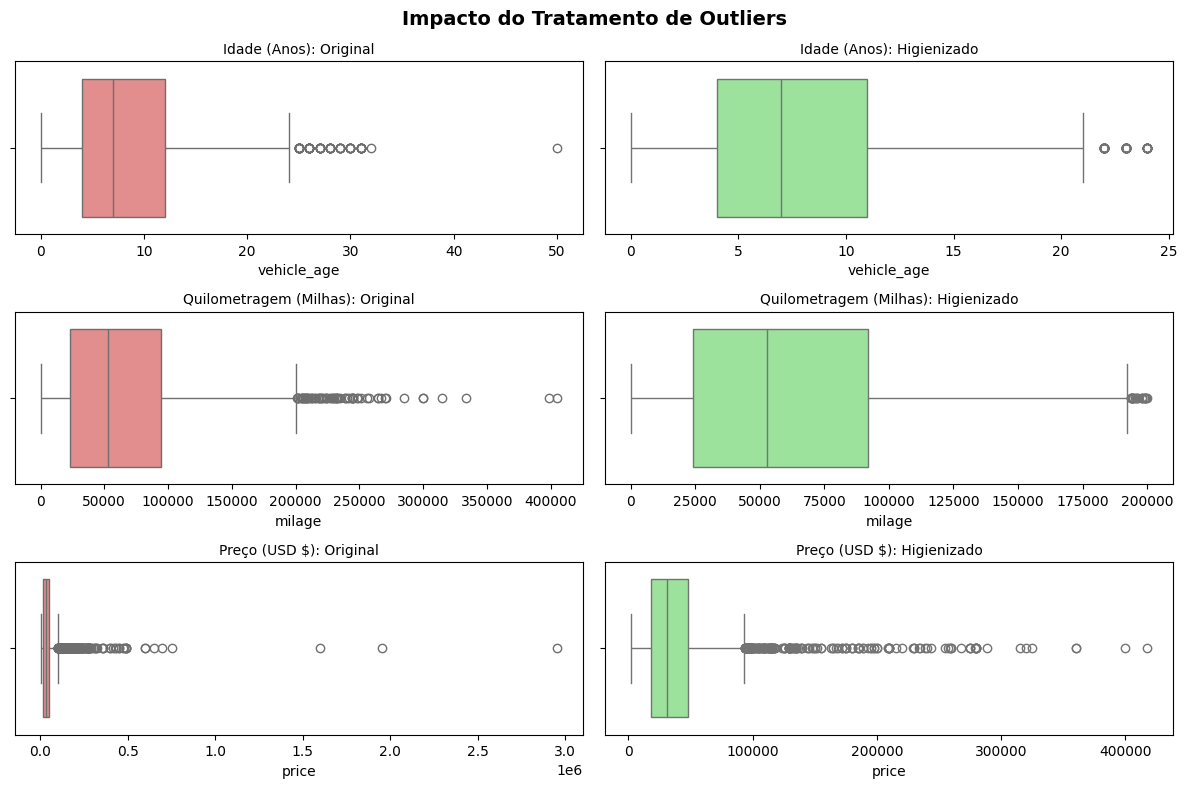

In [2350]:
# Boxplots das variáveis tratadas, antes e depois da remoção de outliers

# Define as variáveis que queremos plotar
features = [
    ('vehicle_age', 'Idade (Anos)'),
    ('milage', 'Quilometragem (Milhas)'),
    ('price', 'Preço (USD $)')
]

# Configura a caixa de espaço dos gráficos (matriz 3 x 2)
fig, axes = plt.subplots(len(features), 2, figsize=(12, 8))
fig.suptitle('Impacto do Tratamento de Outliers', fontsize=14, fontweight='bold')

cor_antes = 'lightcoral'
cor_depois = 'lightgreen'

# Para cada variável definida anteriormente plota o boxplot de antes e depois do tratamento de outliers
for i, (col, label) in enumerate(features):

    # Plota boxplot dos dados originais
    sns.boxplot(x=df_cars[col], ax=axes[i, 0], color=cor_antes)
    axes[i, 0].set_title(f'{label}: Original', fontsize=10)

    # Plota boxplor dos dados após remoção de outlier
    sns.boxplot(x=df_cars_clean[col], ax=axes[i, 1], color=cor_depois)
    axes[i, 1].set_title(f'{label}: Higienizado', fontsize=10)

# Ajustes finais
#plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.tight_layout()
plt.show()

A limpeza de 7,5% da base (299 registros) focou na remoção das exceções de mercado, permitindo que os seguintes efeitos fossem observados:

* A variável com ajuste mais significativo foi o preço (*price*). A redução da amplitude máxima — que baixou da casa dos milhões para o teto de 399 mil USD — reduziu drasticamente o desvio padrão, garantindo que o algoritmo de regressão não sofra distorções por conta de veículos que operam em uma lógica de valor completamente distinta da média do mercado.

* Ao limitar a idade em 24 anos e a quilometragem em 200k milhas, o modelo deixa de tentar aprender com nichos de baixa amostragem, como veículos colecionáveis ou de altíssima rodagem, e passa a focar onde há maior densidade de dados e maior relevância para a maioria das transações.

* Em todas as variáveis, observamos que a média e a mediana se aproximaram. No cenário original, a média era artificialmente deslocada para cima pelos valores extremos, mas agora ela reflete com maior fidelidade o comportamento da massa de dados e da tendência central do mercado.

* Com a redução do intervalo total de valores, houve uma expansão visual das áreas ocupadas pelas caixas nos gráficos. O gráfico agora dispõe de escala para detalhar a variação entre o primeiro e o terceiro quartil (Q1 e Q3), que antes era visualmente comprimida pelos extremos.

Dessa forma, o dataset final consolida-se como uma base especialista em veículos de circulação comercial padrão, mitigando a influência de modelos de hiper luxo ou colecionáveis que operam sob lógicas de valor diferenciadas.

Para finalizar esta etapa, filtramos o dataset higienizado mantendo apenas as variáveis relevantes para as análises finais, descartando colunas auxiliares ou com dados brutos que já foram processados.

In [2351]:
# Informação dos colunas do dataset em estudo, incluindo o tipo de dado de cada atributo

df_cars_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3753 entries, 0 to 3880
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 3753 non-null   object 
 1   model                 3753 non-null   object 
 2   model_year            3753 non-null   int64  
 3   milage                3753 non-null   float64
 4   fuel_type             3753 non-null   object 
 5   engine                3753 non-null   object 
 6   transmission          3753 non-null   object 
 7   ext_col               3753 non-null   object 
 8   int_col               3753 non-null   object 
 9   accident              3753 non-null   object 
 10  price                 3753 non-null   float64
 11  brand_tier            3753 non-null   object 
 12  model_persona         3753 non-null   object 
 13  fuel_group            3753 non-null   object 
 14  engine_std            3753 non-null   object 
 15  engine_config         3753

In [2352]:
# Selecionando no dataset limpo apenas as colunas de interesse para análise

# Antes de treinar um modelo deveríamos ainda retirar a coluna segmento_mercado que é apenas uma junção de brand_tier e model_persona
# Por hora, segment_mercado permanece porque será útil nas análises de hipóteses

# Define lista de colunas de interesse para análises finais
cols_analise = [
    'segmento_mercado', 'brand_tier', 'model_persona', 'vehicle_age',
    'milage', 'fuel_group', 'engine_config', 'engine_hp',
    'engine_displacement', 'is_turbo', 'transmission_grouped',
    'ext_col_group', 'int_col_group', 'accident', 'price'
]

# Copia para o dataframe limpo apenas as colunas de interesse
df_cars_clean = df_cars_clean[cols_analise].copy()

# Exibe primeiras linhas de novo dataframe limpo e selecionado
df_cars_clean.head()

,segmento_mercado,brand_tier,model_persona,vehicle_age,milage,fuel_group,engine_config,engine_hp,engine_displacement,is_turbo,transmission_grouped,ext_col_group,int_col_group,accident,price
0,Mainstream_Daily_Standard,Mainstream,Daily_Standard,11,51000.0,Other Combustion,Mid_Performance,300.0,3.7,False,Automatic,Neutral_Dark,Standard_Dark,At least 1 accident or damage reported,10300.0
1,Mainstream_Luxury_Premium,Mainstream,Luxury_Premium,3,34742.0,Gasoline,Mid_Performance,304.0,3.8,False,Automatic,Vibrant_Rare,Standard_Light,At least 1 accident or damage reported,38005.0
2,Premium_Luxury_Premium,Premium,Luxury_Premium,2,22372.0,Gasoline,Sem Informação,305.0,3.5,False,Automatic,Chroma_Standard,Standard_Dark,None reported,54598.0
3,Premium_Daily_Standard,Premium,Daily_Standard,9,88900.0,Green Energy,Mid_Performance,354.0,3.5,False,Automatic,Neutral_Dark,Standard_Dark,None reported,15500.0
4,Premium_Daily_Standard,Premium,Daily_Standard,3,9835.0,Gasoline,Entry_Standard,206.0,2.0,True,Automatic,Neutral_Light,Standard_Dark,None reported,34999.0


## 5.4 Transformação de dados: Dummy Encoding

Nesta seção, realizamos a conversão das **variáveis categóricas** em um formato numérico processável, através da técnica de **Dummy Encoding**. Este passo é crucial, pois algoritmos de regressão operam sobre matrizes matemáticas e não conseguem interpretar dados textuais diretamente.

A escolha do Dummy encoding (uma variante do One-Hot Encoding), busca evitar problemas de multicolinearidade, ao omitir uma variável de referência (n-1) para cada grupo.

Optou-se ainda pelo Dummy Encoding em vez do Ordinal para evitar hierarquias artificiais, visto que as distribuições de preço revelaram, mesmo para as variáveis com hierarquia aparente (como *brand_tier*, por exemplo), saltos desproporcionais. Essa abordagem permite que o modelo capture variações não lineares e especificidades de cada nicho.

Dado que a alta cardinalidade original foi previamente mitigada pela criação de agrupamentos semânticos, o impacto na dimensionalidade do dataset permanece controlado, resultando em um conjunto de colunas binárias eficientes para o treinamento do modelo.

In [2353]:
# Aplicando Dummy Encoding no conjunto de dados limpo

# Remove a coluna segmento_mercado por ser uma combinação de brand_tier e model_persona
df_temp = df_cars_clean.drop(columns=['segmento_mercado'])

# Seleciona as colunas categóricas
categorical_cols = df_temp.select_dtypes(include=['object', 'bool']).columns

# Escolhe a transformação Dummy Encoding
# drop='first': Remove a primeira categoria de cada coluna para evitar multicolinearidade
# sparse_output=False: Retorna um array denso para facilitar a reconstrução do DataFrame
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Transforma os dados nas colunas selecionadas
encoder_array = encoder.fit_transform(df_temp[categorical_cols])

# Constroi DataFrame com os valores transformados e com os nomes das colunas geradas pelo encoder
encoder_df = pd.DataFrame(encoder_array,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_temp.index)

# Cria dataframe final, unindo as colunas originais numéricas com as categóricas tratadas
# Removemos as originais de texto e acoplamos as binárias
df_cars_final = pd.concat([df_temp.drop(columns=categorical_cols), encoder_df], axis=1)

# Exibe primeira linhas do dataframe encoding
df_cars_final.head()

,vehicle_age,milage,engine_hp,engine_displacement,price,brand_tier_Mainstream,brand_tier_Premium,model_persona_Heavy_Duty_Utility,model_persona_High_Performance,model_persona_Luxury_Premium,...,transmission_grouped_Manual,ext_col_group_Earth_Tones,ext_col_group_Neutral_Dark,ext_col_group_Neutral_Light,ext_col_group_Vibrant_Rare,int_col_group_Exotic_Rare,int_col_group_Premium_Earth,int_col_group_Standard_Dark,int_col_group_Standard_Light,accident_None reported
0,11,51000.0,300.0,3.7,10300.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,34742.0,304.0,3.8,38005.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,22372.0,305.0,3.5,54598.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,88900.0,354.0,3.5,15500.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,3,9835.0,206.0,2.0,34999.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


## 5.5 Transformação de dados: Normalização

Nesta etapa, aplicamos a **Normalização** às variáveis numéricas preditoras: ***vehicle_age, milage, engine_hp e engine_displacement***. Esta transformação é fundamental para garantir que todas as variáveis numéricas estejam contidas no mesmo intervalo [0, 1], evitando que o modelo de regressão atribua importância desproporcional a atributos com maiores ordens de grandeza, como a quilometragem em relação à idade do veículo.

A escolha pela Normalização em detrimento da Padronização justifica-se pelo fato de as variáveis do projeto não seguirem necessariamente uma distribuição normal. A Normalização preserva a estrutura original das distâncias entre os dados, apenas comprimindo-os em uma escala comum, o que facilita a convergência de algoritmos de aprendizado de máquina sem distorcer a relação entre os atributos.

Mantivemos a variável *price* em sua escala original para garantir a interpretabilidade direta dos resultados em moeda, facilitando a análise de negócio. Além disso, o tratamento prévio de outliers via IQR já estabilizou a distribuição, tornando a normalização do target desnecessária para o desempenho do modelo.

In [2354]:
# Aplicando a normalização nas colunas originalmente numéricas vehicle_age, milage, engine_hp e engine_displacement

# Seleciona as colunas originalmente numéricas que queremos normalizar
cols_to_scale = ['vehicle_age', 'milage', 'engine_hp', 'engine_displacement']

# Aplica a normalização das colunas selecionadas já no dataframe final
df_cars_final[cols_to_scale] = MinMaxScaler().fit_transform(df_cars_final[cols_to_scale])

# Visualiza dataframe pronto para modelagem
df_cars_final.head()

,vehicle_age,milage,engine_hp,engine_displacement,price,brand_tier_Mainstream,brand_tier_Premium,model_persona_Heavy_Duty_Utility,model_persona_High_Performance,model_persona_Luxury_Premium,...,transmission_grouped_Manual,ext_col_group_Earth_Tones,ext_col_group_Neutral_Dark,ext_col_group_Neutral_Light,ext_col_group_Vibrant_Rare,int_col_group_Exotic_Rare,int_col_group_Premium_Earth,int_col_group_Standard_Dark,int_col_group_Standard_Light,accident_None reported
0,0.458333,0.254627,0.242105,0.445783,10300.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.125000,0.173297,0.246316,0.457831,38005.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.083333,0.111416,0.247368,0.421687,54598.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.375000,0.444222,0.298947,0.421687,15500.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.125000,0.048699,0.143158,0.240964,34999.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


**Nota Técnica: Prevenção de Data Leakage**

É importante ressaltar que, para a futura etapa de modelagem preditiva, o Split entre treino e teste deve preceder as seguintes transformações realizadas neste projeto:

* Tratamento de Dados Ausentes por Mediana (Motores): A imputação de *engine_hp* e *engine_displacement* utiliza a mediana dos grupos. Para evitar o vazamento de dados, essa mediana deve ser calculada apenas com os dados de treino e replicada no teste.

* Tratamento de Outliers: Os limites de corte (IQR) devem ser definidos com base na distribuição do conjunto de treino.

* Dummy Encoding: Deve-se garantir que as categorias presentes no teste sejam mapeadas conforme o aprendizado no treino.

* Normalização: O ajuste do MinMaxScaler deve ser feito estritamente sobre o treino para que o modelo não tenha ciência antecipada da amplitude total dos dados de teste.

A execução dessas etapas no dataset completo durante este projeto teve caráter exploratório e de viabilidade técnica.

# 6. Análises Finais

## 6.1 Análise de correlação

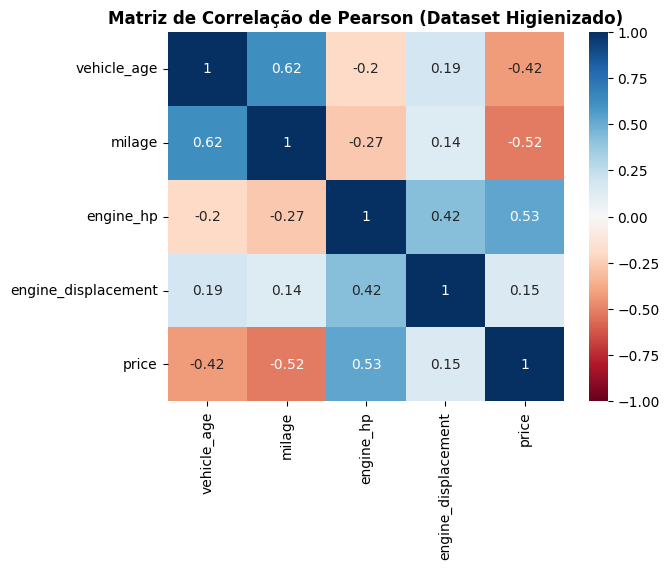

In [2355]:
# Heatmap da correlação de Pearson entre variáveis numéricas do dataset higienizado

sns.heatmap(df_cars_clean.select_dtypes(include='number').corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1)

plt.title('Matriz de Correlação de Pearson (Dataset Higienizado)', fontsize=12, fontweight='bold');

A matriz de correlação revela relações coerentes com a dinâmica do mercado automotivo:

* O Preço (***price***) apresenta correlações moderadas com as principais variáveis. A maior força de associação positiva vem da potência (***engine_hp*: 0.53**), indicando que cavalaria é um preditor consistente de valor. No sentido oposto, a quilometragem (***milage*: -0.52**) exerce uma influência negativa ligeiramente superior à idade do veículo (***vehicle_age*: -0.42**). Isso sugere que, para este dataset, o desgaste físico (uso) impacta mais o valor de revenda do que o tempo de existência do carro.

* Observamos uma correlação moderada (0.62) entre ***vehicle_age e milage***. Ela confirma que carros mais velhos tendem a ser mais rodados. Para o modelo, isso significa que essas duas variáveis carregam informações parcialmente redundantes. Já a relação entre potência (***engine_hp***) e cilindrada (***engine_displacement***) é de 0.42, um valor moderado que indica que motores maiores nem sempre são os mais potentes.

* A variável ***engine_displacement*** possui a menor correlação direta com o preço (0.15). Isso é um insight importante: o mercado parece precificar o carro pela performance entregue (hp) e não necessariamente pelo tamanho do motor em litros. Em termos de modelagem linear, esta variável isolada contribui pouco para explicar a variação do preço.

## 6.2 Analisando as hipóteses iniciais

### **Hipótese 1:** Tendência de Depreciação por Idade

Nos principais segmentos, quanto mais antigos os modelos, menor o preço do automóvel.

Para começar vamos definir quais são os principais segmentos de mercado (cobrem ~80% da nossa base), e vamos criar um dataset focado nestes top segmentos.

In [2356]:
# Distribuição de frequencia da variável segmento_mercado, após tratamento de outliers

analisar_distribuicao(df_cars_clean, 'segmento_mercado')

--- Análise da Variável: segmento_mercado ---
Total de classes únicas: 12

                                  Frequência Absoluta  Frequência Relativa (%)
segmento_mercado                                                              
Mainstream_Daily_Standard                        1071                    28.54
Premium_Daily_Standard                            763                    20.33
Mainstream_Heavy_Duty_Utility                     456                    12.15
Premium_Luxury_Premium                            416                    11.08
Premium_High_Performance                          254                     6.77
Mainstream_High_Performance                       173                     4.61
Luxury_Exotic_Luxury_Premium                      169                     4.50
Luxury_Exotic_High_Performance                    161                     4.29
Mainstream_Luxury_Premium                         158                     4.21
Luxury_Exotic_Daily_Standard                       93   

In [2357]:
# Define a lista dos top 5 segmentos
top_5_segmentos = [
    'Mainstream_Daily_Standard',
    'Premium_Daily_Standard',
    'Mainstream_Heavy_Duty_Utility',
    'Premium_Luxury_Premium',
    'Premium_High_Performance'
]

# Cria o dataset focado apenas neles
df_top_segments = df_cars_clean[df_cars_clean['segmento_mercado'].isin(top_5_segmentos)].copy()

# Confere qual o percentual da base foi selecionado
print(f"Registros após filtro: {len(df_top_segments)}")
print(f"Representatividade: {(len(df_top_segments) / len(df_cars_clean)) * 100:.2f}%")

Registros após filtro: 2960
Representatividade: 78.87%


A análise foi concentrada nos 5 segmentos de mercado com maior volume de dados, que juntos representam aproximadamente 79% da base total. Esta decisão visa assegurar a robustez dos resultados e mitigar distorções causadas por nichos de baixa amostragem (inferiores a 1% da base).

In [2358]:
# Define função que plota scatterplots de variável x preço e
# calcula o coeficiente de correlação de Pearson, para cada um dos top 5 segmentos de mercado

def scatter_pearson_price(df, variavel):

    # Estrutura a moldura do gráfico (formato 2 x 3) e insere título global
    fig, ax = plt.subplots(2, 3, figsize=(18, 12))
    plt.suptitle("Análise de Depreciação: Idade do Veículo vs Preço", fontsize=16)

    # Inicia a variável que vai conter a informação do coeficiente de correlação para cada segmento
    metrics = []

    # Itera os comandos a seguir pelos top 5 segmentos selecionados anteriormente
    for idx, segmento in enumerate(top_5_segmentos):

        # Transforma o índice dos segmentos na respectiva posição de linha e coluna
        row = idx // 3
        col = idx % 3

        # Filtra apenas os dados referentes ao segmento desta iteração
        subset = df[df['segmento_mercado'] == segmento]

        # Calcula o coeficiente de correlação de Pearson para variável x preço
        r_corr = pearsonr(subset[variavel], subset['price'])[0]

        # Classifica se o coeficiente encontrado é forte ou não
        if r_corr < -0.70:
            status = "Forte"
        elif r_corr < -0.50:
            status = "Moderada"
        else:
            status = "Fraca"

        # Armazena dados da correlação para o resumo final
        metrics.append({'Segmento': segmento, 'Pearson_r': r_corr, 'Status': status})

        # Plota scatterplot com linha de tendência no subplot específico
        sns.regplot(
            data=subset,
            x=variavel,
            y='price',
            ax=ax[row][col],
            scatter_kws={'alpha': 0.2, 's': 10}, # Deixa pontos do gráfico transparentes e menores
            line_kws={'color': 'red', 'label': f'Trend: r={r_corr:.2f}'}
        )

        # Insere títulos e legenda em cada subplot
        ax[row][col].set_title(f"{segmento}\nForça: {status}", fontsize=12)
        ax[row][col].set_xlabel(f"{variavel}")
        ax[row][col].set_ylabel("Preço")
        ax[row][col].legend()

    # Apaga eixos do subplot que não foi utilizado
    fig.delaxes(ax[1][2])

    # Ajusta layout e exibe
    plt.tight_layout()
    plt.show()

    # Transforma a lista metrics em um dataframe para ser exibido
    df_resumo = pd.DataFrame(metrics).sort_values(by='Pearson_r')
    print(df_resumo)

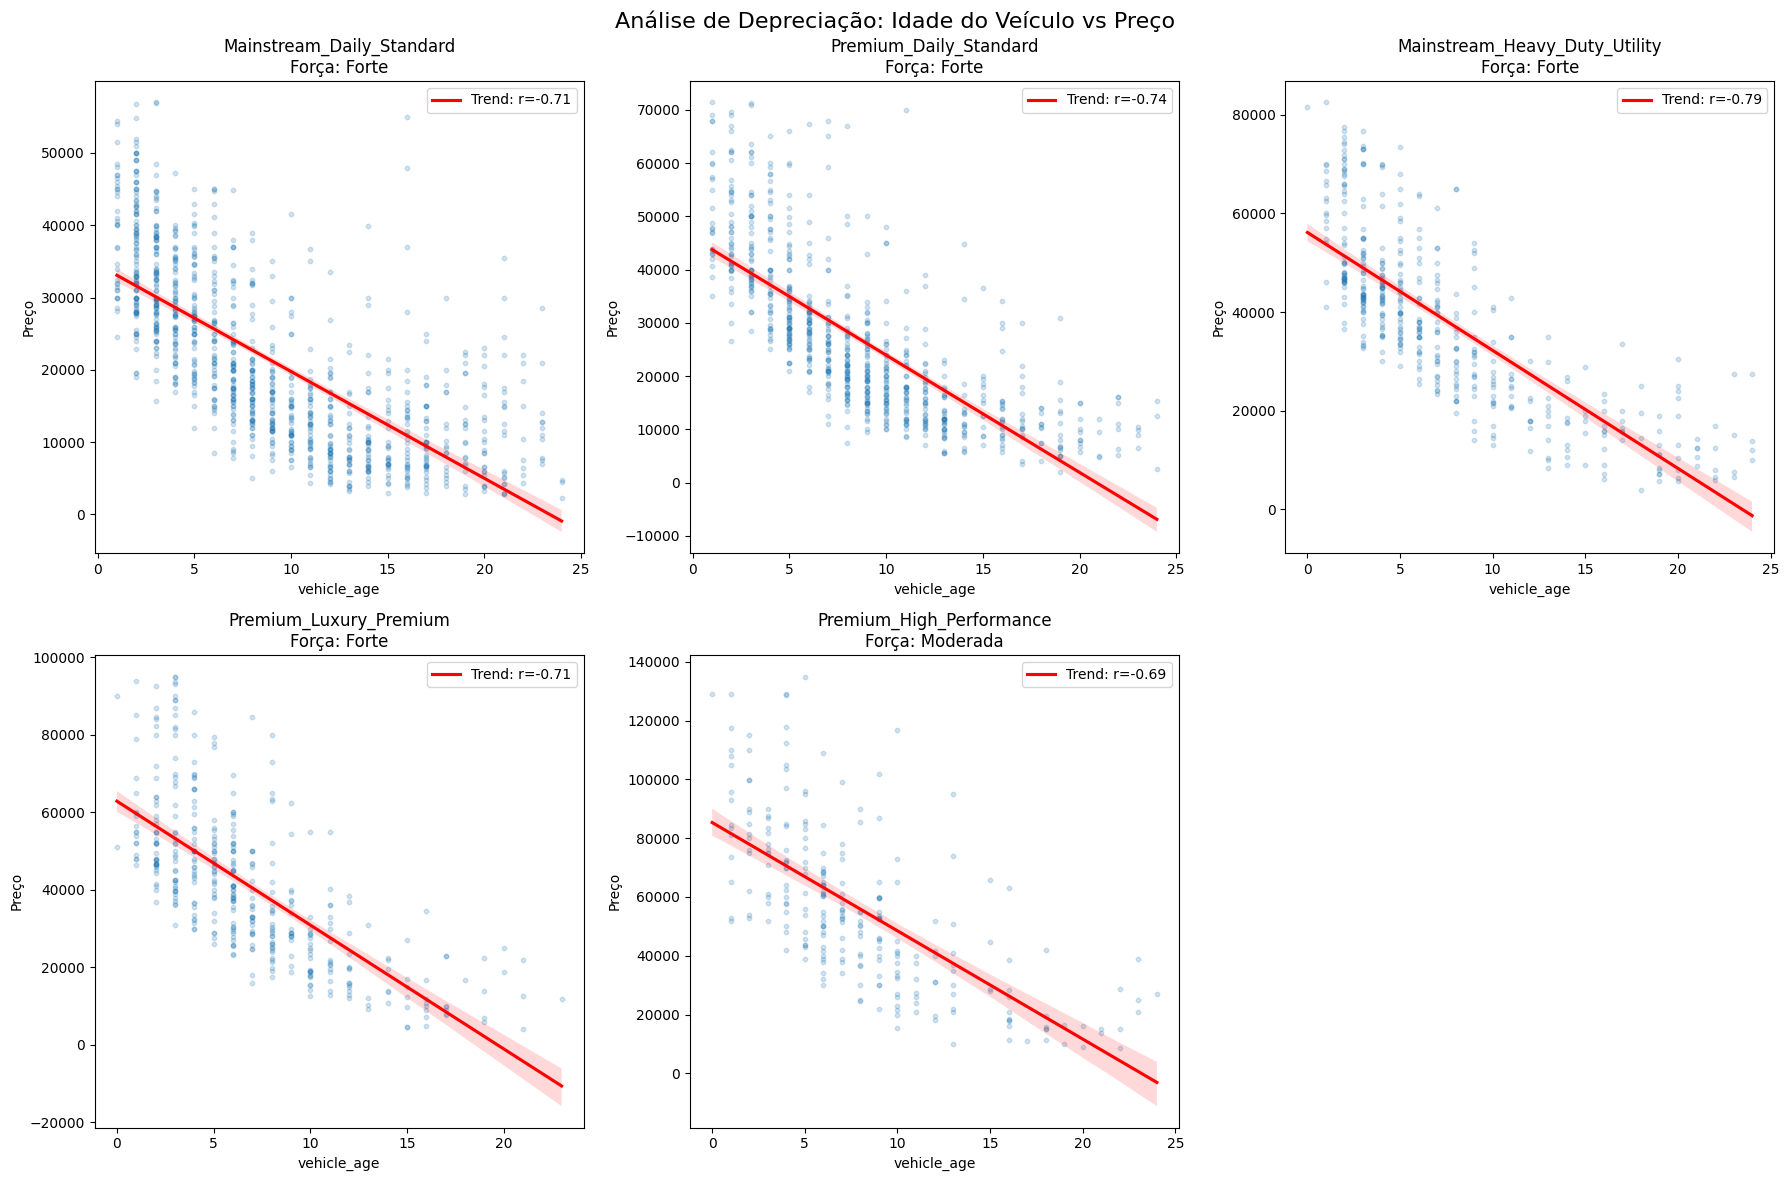

                        Segmento  Pearson_r    Status
2  Mainstream_Heavy_Duty_Utility  -0.787597     Forte
1         Premium_Daily_Standard  -0.743729     Forte
3         Premium_Luxury_Premium  -0.712164     Forte
0      Mainstream_Daily_Standard  -0.710952     Forte
4       Premium_High_Performance  -0.690117  Moderada


In [2359]:
# Chamada da função acima para a variável vehicle_age

scatter_pearson_price(df_top_segments, 'vehicle_age')

A análise realizada sobre o recorte dos 5 principais segmentos de mercado (representando aproximadamente 79% da base de dados) confirmou a existência de uma **forte correlação negativa** entre a idade do veículo (*vehicle_age*) e o seu preço de mercado (*price*), **confirmando a hipótese inicial**.
* Embora a matriz de correlação global do dataset apresentasse um coeficiente de Pearson moderado (r = -0,42), a análise estratificada revelou que este valor estava diluído pela heterogeneidade dos dados. Ao isolar os principais segmentos, observamos coeficientes significativamente mais expressivos.
* Quatro dos cinco maiores segmentos apresentaram uma relação linear negativa alta. O destaque foi o segmento Mainstream_Heavy_Duty_Utility (r = -0,79), indicando que, para veículos utilitários, o fator tempo é um preditor de valor mais relevante que para os demais segmentos.
* Apenas o segmento Premium_High_Performance (r = -0,69) situou-se ligeiramente abaixo do limiar considerado (r= -0,7). Este comportamento sugere que, em categorias de nicho ou alta performance, variáveis subjetivas (como raridade e estado de conservação) podem exercer uma resistência maior à depreciação temporal cronológica.
* A análise visual através de Scatter Plots e linhas de regressão sugere que a queda de preço não é perfeitamente uniforme. Observa-se uma concentração maior de perda de valor nos primeiros anos de uso, com uma tendência de estabilização em veículos com idade avançada, caracterizando um potencial comportamento de depreciação exponencial em vez de puramente linear. Apesar dessa curvatura, a força do coeficiente de Pearson confirma a tendência linear como uma aproximação robusta para os dados em estudo.

### **Hipótese 2:** Relação entre Uso e Valor

Nos principais segmentos, veículos com maior quilometragem acumulada apresentam preços inferiores aos de baixa quilometragem.

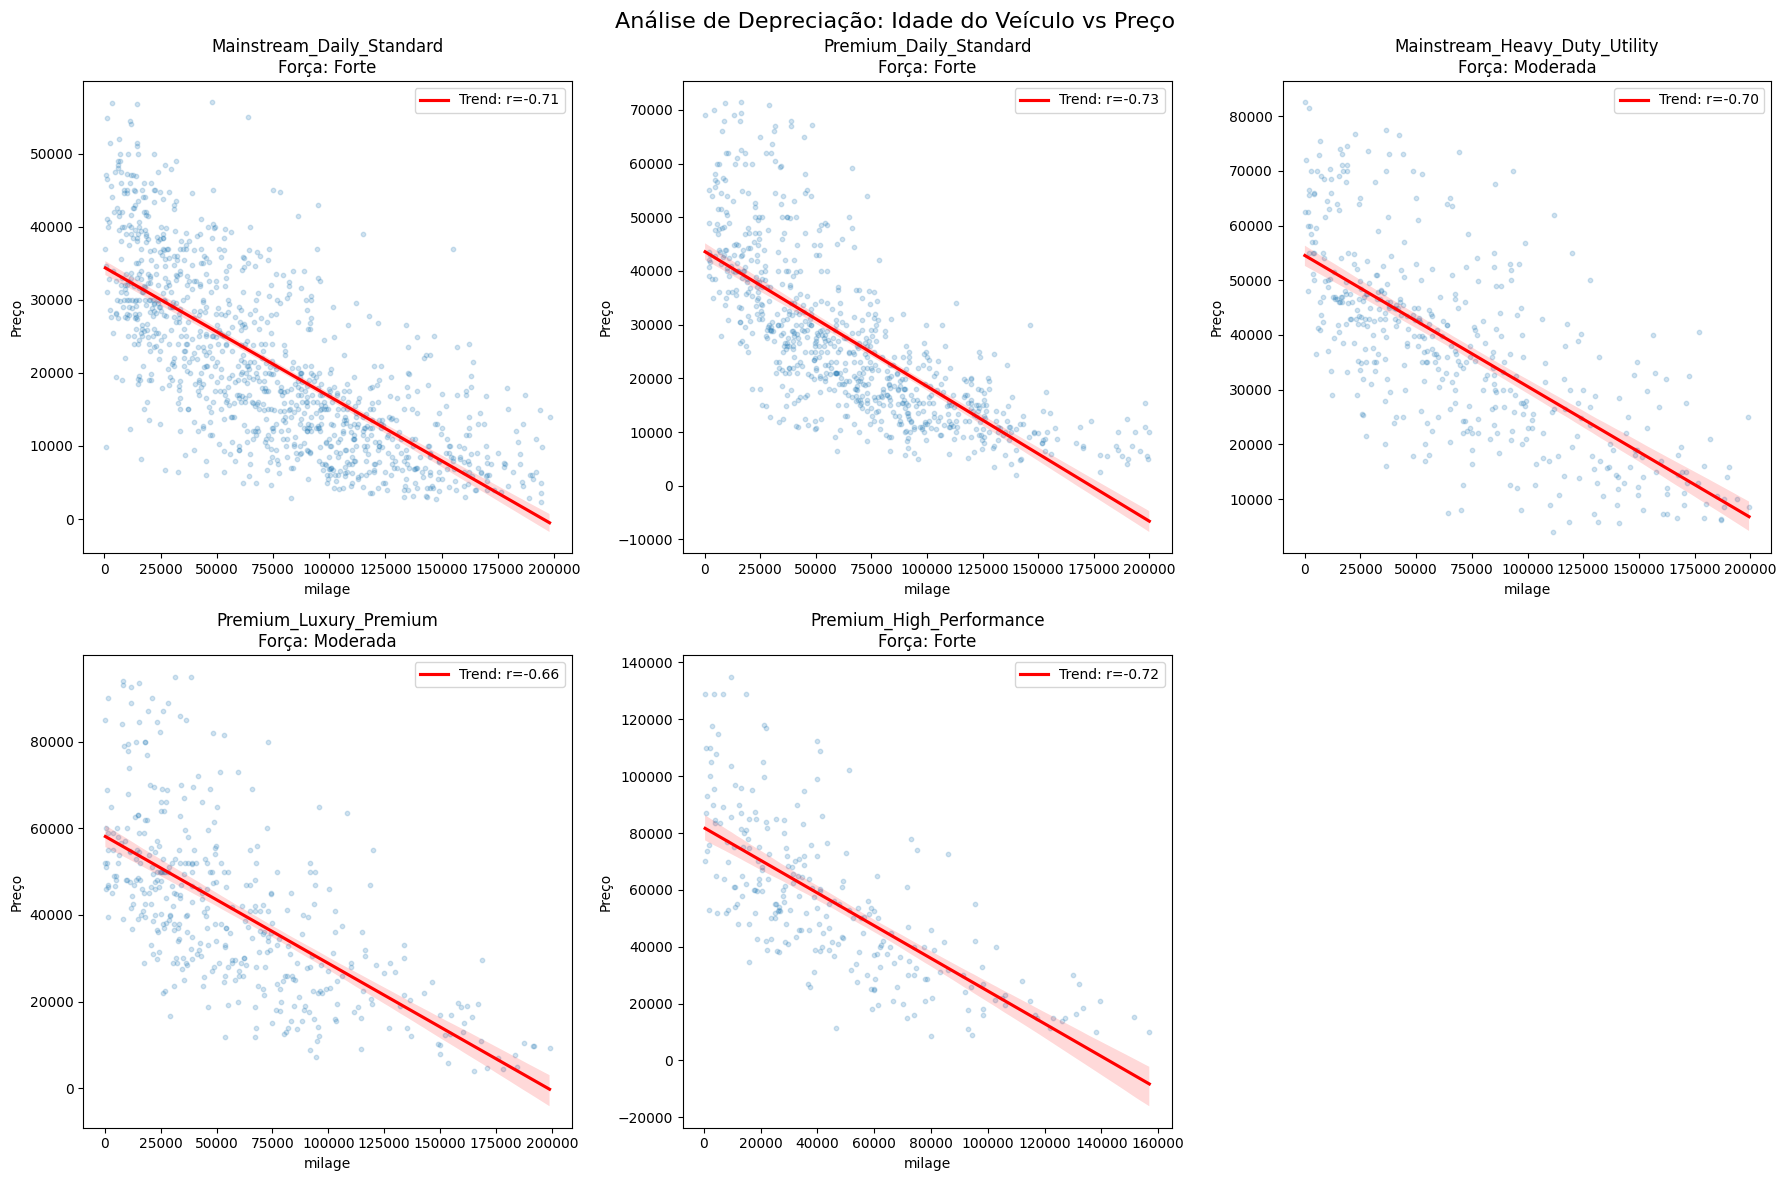

                        Segmento  Pearson_r    Status
1         Premium_Daily_Standard  -0.728741     Forte
4       Premium_High_Performance  -0.717700     Forte
0      Mainstream_Daily_Standard  -0.713948     Forte
2  Mainstream_Heavy_Duty_Utility  -0.698015  Moderada
3         Premium_Luxury_Premium  -0.655081  Moderada


In [2360]:
# Chamada da função que cria scatterplots variável x preço, para a variável milage

scatter_pearson_price(df_top_segments, 'milage')

A análise realizada sobre o recorte dos 5 principais segmentos de mercado confirmou a existência de uma **forte/moderada correlação negativa** entre a quilometragem acumulada (*milage*) e o preço de mercado (*price*), **validando a premissa** de que o uso intensivo é um fator significativo de desvalorização.
* Assim como observado na análise de idade, a correlação global de quilometragem no dataset completo era inferior à encontrada nos segmentos específicos. A estratificação permitiu identificar que o impacto do uso é muito mais pronunciado quando analisamos categorias de mercado homogêneas, eliminando o ruído de preços entre diferentes nichos.
* Três dos cinco maiores segmentos apresentaram correlação forte (r < -0,70). Curiosamente, o segmento Premium_Daily_Standard (r = -0,73) liderou a sensibilidade à quilometragem, indicando que compradores de veículos premium de uso diário são mais criteriosos quanto ao desgaste mecânico visível no odômetro.
* Diferente da análise de idade (onde teve a menor correlação), o segmento Premium_High_Performance (r = -0,72) apresentou aqui uma correlação Forte. Isso sugere que, para carros esportivos, o mercado tolera melhor a passagem do tempo (idade) do que o desgaste físico (quilometragem), possivelmente devido aos altos custos de manutenção preventiva associados ao uso desses veículos.
* Os segmentos Mainstream_Heavy_Duty_Utility ($r = -0,70$) e Premium_Luxury_Premium ($r = -0,66$) situaram-se no limiar ou abaixo da correlação forte. No caso dos utilitários pesados, isso indica que o mercado pode aceitar quilometragens mais elevadas como inerentes à função do veículo, enquanto no segmento premium, o prestígio da marca e o nível de equipamentos podem mitigar parcialmente o impacto da alta quilometragem no preço final.

### **Hipótese 3:** Colinearidade entre Variáveis de Desgaste

Existe uma forte correlação positiva entre a quilometragem e a idade de cada veículo (carros mais novos tendem a ter menos milhas rodadas).

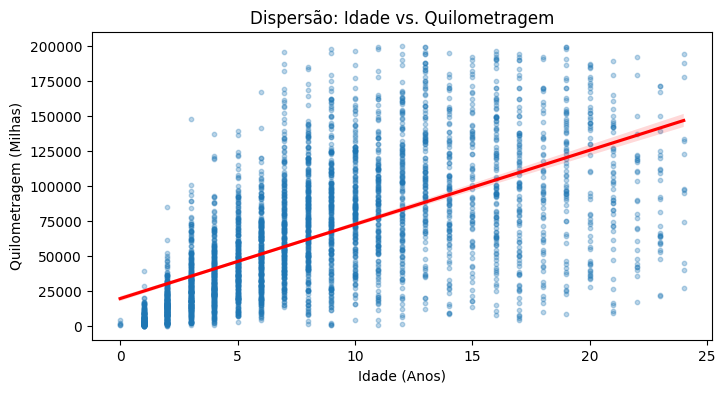

In [2361]:
# Scatterplot das variáveis vehicle_age x milage, com linha de tendência

# Cria moldura do gráfico
plt.figure(figsize=(8, 4))

# Desenha os pontos e a linha de tendência
sns.regplot(data=df_cars_clean, x='vehicle_age', y='milage',
            scatter_kws={'alpha':0.3, 's':10}, # Transparência e tamanho dos pontos
            line_kws={'color':'red'})

# Inclui títulos
plt.title('Dispersão: Idade vs. Quilometragem', fontsize=12)
plt.xlabel('Idade (Anos)')
plt.ylabel('Quilometragem (Milhas)')

# Exibe gráfico
plt.show()

* A hipótese de "forte correlação" foi rejeitada, demonstrando-se apenas moderada na prática. O coeficiente de Pearson (0,62) situa-se abaixo do patamar de 0,70, indicando que a relação entre as variáveis não é suficientemente estreita para caracterizar colinearidade.

* Embora o índice não atinja o nível de forte dependência, os dados confirmam uma tendência de aumento da quilometragem com o avanço da idade, validando o comportamento esperado de uso contínuo ao longo do tempo.

* O gráfico de dispersão apresenta uma nuvem de pontos dispersa e não linearmente estreita. Essa distribuição confirma que veículos da mesma idade apresentam variações significativas de quilometragem, indicando que o tempo cronológico não é o único determinante do uso real.

* Dada a ausência de colinearidade forte, ambas as variáveis serão mantidas como preditoras. O modelo precisará de ambas para distinguir, por exemplo, entre um veículo antigo conservado e um veículo antigo de uso severo.


### **Hipótese 4:** Impacto do Histórico de Acidentes

O registro de acidentes prévios desvaloriza o automóvel em comparação com veículos similares sem sinistro.

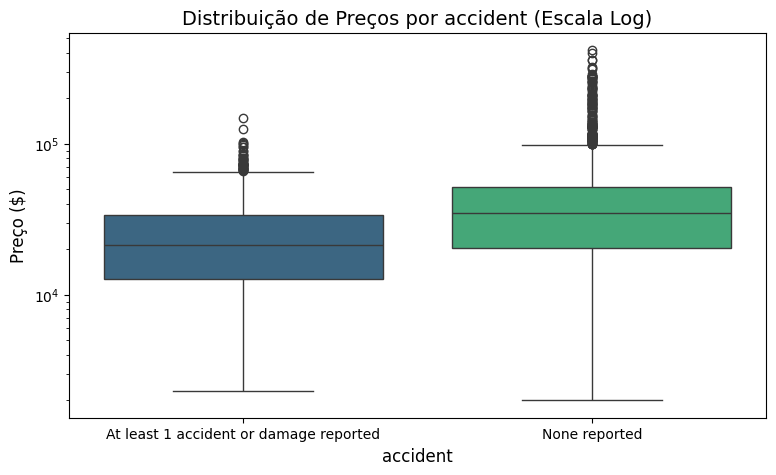

In [2362]:
# Criando boxplot dos preços de veículos, nas classes da variável accident

boxplot_price(df_cars_clean, 'accident')

In [2363]:
# Verifica estatísticas da variável price nos grupos com e sem acidentes registrados

comparativo_precos = df_cars_clean.groupby('accident')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos.to_string())

                                                mean   median  count           std     min       max
accident                                                                                            
At least 1 accident or damage reported  26100.680258  21500.0    932  18590.703808  2300.0  147500.0
None reported                           43549.792627  35000.0   2821  39417.395073  2000.0  417500.0


Os dados corroboram a hipótese de que o histórico de sinistros impacta negativamente o valor de revenda, uma vez que a mediana de preços de veículos sem acidentes registrados (35.000 USD) é aproximadamente 62% superior à de veículos com histórico de danos (21.500 USD).

Embora o desvio padrão elevado em ambos os grupos indique que outros fatores também influenciam o preço final, a queda consistente tanto na média quanto na mediana confirma que o registro de acidentes atua como detrator de valor no mercado de usados.

O boxplot reforça visualmente essa tendência de desvalorização: embora haja uma zona de intersecção entre os preços, nota-se um claro deslocamento vertical das caixas.

### **Hipótese 5**: Prevalência da Transmissão Automática

Veículos mais novos apresentam uma proporção de câmbio automático significativamente superior à observada em modelos mais antigos.

In [2364]:
# Calculando a proporção de veículos com transmissão automática e manual, ano a ano
tab_transmissao = pd.crosstab(df_cars_clean['vehicle_age'],
                             df_cars_clean['transmission_grouped'],
                             normalize='index') * 100

# Ordena as idades do mais antigo para o mais novo
tab_transmissao = tab_transmissao.sort_index(ascending=False)

# Imprime a tabela
tab_transmissao


transmission_grouped,Automatic,Manual
vehicle_age,,
24,61.538462,38.461538
23,55.172414,44.827586
22,60.714286,39.285714
21,53.191489,46.808511
20,81.481481,18.518519
19,73.134328,26.865672
18,74.137931,25.862069
17,79.347826,20.652174
16,76.851852,23.148148


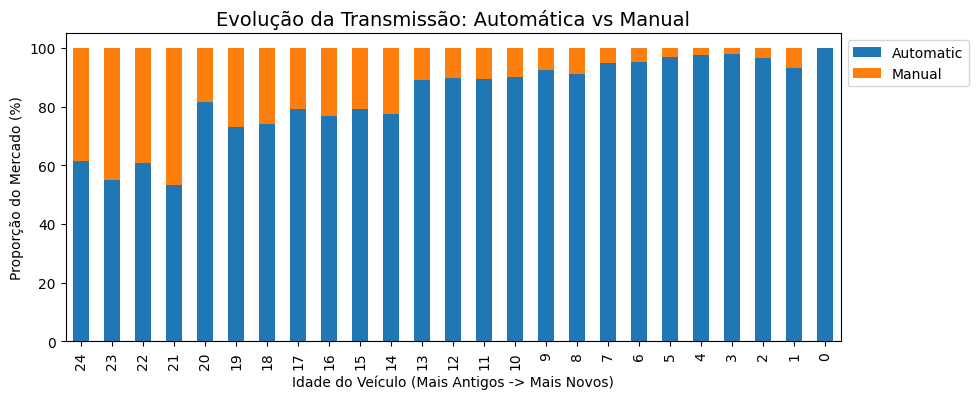

In [2365]:
# Plotando o gráfico que mostra a proporção de carros automáticos x manuais, ano a ano
tab_transmissao.plot(kind='bar', stacked=True, figsize=(10,4))

# Inclui títulos e legenda
plt.title('Evolução da Transmissão: Automática vs Manual', fontsize=14)
plt.xlabel('Idade do Veículo (Mais Antigos -> Mais Novos)')
plt.ylabel('Proporção do Mercado (%)')
plt.legend(bbox_to_anchor=(1,1)) # Argumento garante que a legenda vai ficar fora do gráfico

# Exibe o gráfico
plt.show()

Considerando a premissa de que nossa base de estudos contém amostras representativas do mercado em cada ano, a análise confirma que modelos mais novos apresentam uma **proporção de câmbio automático significativamente maior** do que a observada em veículos antigos. Embora a transmissão automática já fosse majoritária em 2000 (Ano 24), representando 61% da base, sua dominância se intensificou, atingindo 93% em 2023 (Ano 1).

O gráfico revela que essa transição não é perfeitamente linear, existem oscilações pontuais onde a presença de manuais cresce momentaneamente em determinadas safras. Entretanto, essas variações não anulam a tendência macro: o câmbio manual, que ocupava quase 40% do mercado no início da série, tornou-se residual na última década. Essa mudança reflete uma padronização da indústria em torno do conforto e da automação.

# 7. Conclusão

Este projeto percorreu as etapas de Análise Exploratória e Pré-processamento de Dados, parte do ciclo fundamental de Ciência de Dados, transformando uma base de dados bruta de web scraping em um conjunto de informações estruturadas e prontas para modelagem preditiva. Os tratamentos realizados permitiram não apenas limpar os dados, mas extrair inteligência de negócio sobre a dinâmica do mercado automobilístico americano em 2023, conforme resumido abaixo:

* **Engenharia de Atributos**: A extração de dados técnicos (configuração do motor, HP, cilindrada e turbo) via RegEx e a criação de "Personas" de modelos e "Tiers" de marcas permitiram reduzir a alta cardinalidade original, transformando textos despadronizados em informação estruturada. O agrupamento dos tipos de combustível, transmissão e cores também contribuiu para redução da cardinalidade excessiva dos atributos.

* **Tratamento de Dados Ausentes**: Para cada atributo, utilizamos lógica específica para imputar valores (como o preenchimento de *fuel_type* Electric para motores elétricos) e binarização interpretativa de *accident*, fundamentada no comportamento estatístico similar entre as classes. Essa abordagem permitiu preservar a volumetria e a riqueza do dataset.

* **Gestão de Outliers**: A aplicação do IQR por segmento de mercado foi fundamental para diminuir a variância do target (*price*) sem excluir os veículos de luxo e performance, garantindo que o modelo possa aprender as nuances de diferentes faixas de preço. A mesma metodologia (IQR) foi utilizada para uma limpeza geral das variáveis quilometragem (*milage*) e idade do veículo (*vehicle_age*).

* **Preparação para Machine Learning**: As etapas de Normalização e a aplicação de Dummy Encoding asseguraram que os dados estivessem em escalas comparáveis e matematicamente aptos para diversos algoritmos de regressão.

As cinco hipóteses levantadas foram validadas:

1. **Tendência de Depreciação por Idade**: Confirmada. Observou-se uma forte correlação negativa entre a idade do veículo e o preço. A análise estratificada revelou que o segmento de utilitários (Heavy Duty) apresenta a maior sensibilidade à idade entre os grupos analisados (r = -0.79).

2. **Relação entre Uso e Valor**: Confirmada. Veículos com maior quilometragem apresentam, em geral, preços inferiores. O estudo mostrou que, para carros esportivos (High Performance), o mercado penaliza mais o desgaste físico do odômetro (r = -0.72) do que a idade cronológica.

3. **Colinearidade entre Variáveis de Desgaste**: Rejeitada como "forte". Embora mediamente correlacionadas (r = 0.62), o índice não atingiu o patamar de redundância. Isso indica que ambas as variáveis são necessárias para o modelo distinguir veículos antigos conservados de veículos de uso severo.

4. **Impacto do Histórico de Acidentes**: Confirmada. O registro de sinistros atua como um detrator de valor. A mediana de preços de veículos sem acidentes é aproximadamente 62% superior à de veículos com histórico de danos.

5. **Prevalência da Transmissão Automática**: Confirmada. Validou-se uma transição tecnológica massiva: a participação de câmbios manuais tornou-se residual na última década, caindo de 39% em modelos de 2000 para apenas 7% nos registros de 2023, refletindo a padronização do mercado.

O objetivo inicial de fornecer informações assertivas para a precificação de anúncios foi atingido. O dataset final oferece uma base sólida para que vendedores compreendam não apenas o valor médio, mas como as especificidades técnicas ditam a posição de seu veículo no mercado. Como trabalho futuro, este conjunto de dados está apto para o treinamento de modelos de regressão, visando a automação da estimativa de valor.